# Code to make the figures used in Dutta et al, 2026

This notebook has been designed to make the figures used in Dutta et al.
The Gibbs Sampler has been executed for 100k iterations for 3 test cases. Further details can be found on the hydra-pspec-systematic repo.

We use 10 fgmodes to model the foregrounds.

A dummy data set with 60 frequencies and 80 time samples has been used. The power spectrum features of Burba et al 2024 have been preserved while making this data. 

In [1]:
import numpy as np
import emcee

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm, Normalize
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import ImageGrid

from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
import corner

from astropy import units as u
from astropy import constants
from astropy.units import Quantity

import scipy 
from scipy import signal
from scipy.fft import fft, fftshift

import sys

import cmcrameri.cm as cmc
import corner
from tqdm import tqdm

import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs
from plotting_functions import plot_waterfalls,plot_waterfalls_from_dlfr
from plotting_codes import tables as tbl   # presentable diagnostic tables
from plotting_codes.functions import covariance_from_pspec,fourier_operator, data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis



basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


# Setup

## Functions

Quick function to calculate the delay power spectrum of components. Note the normalisation conventions used here

In [2]:
# Check power spectrum
def calc_ps(s):
    # NOTE: This uses inverse FFT instead of FFT to get the right normalisation
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs # CHECK: This takes an average

## Setting constants

In [37]:
Ntimes = 80 #60 #203 #Number of LSTs
Nfreqs = 60 #Number of frequencies
Nfgmodes=10 #Number of foreground modes

freqs = np.linspace(100., 120., 120) ##120) #In MHz, 120 channels
freqs = freqs[:Nfreqs] #Select only the first Nfreqs channels

lsts = np.linspace(0., 1., Ntimes) #LST in hours, 1 hour of data, with Ntimes bins

df = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to("1/ns"))) #Delay transform, in ns

sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j]) #True bsys used in this run

Niter = 100000 #Number of Gibbs iterations
conf_interval=95 #For DPS plots
Nburn = 10 #Burn % 
dl_inds=[[3,4,5,6],[10,11,12,13],[3,3,3,3],[20,21,22,23]] #Delay indices for the 3 cases, used in DPS plots

# Generate noise
fourier_op = fourier_operator(freqs.size, unitary=True)

noise_ps_val = 0.0004 #0.000004 #0.000004 # 0.0004 #Noise power spectrum rms
noise_ps_true = noise_ps_val * np.ones(Nfreqs) 
N_true = covariance_from_pspec(noise_ps_true, fourier_op) #Noise covariance matrix
Ninv = np.diag(1./np.diag(N_true)) # get diagonal, invert, pack back into diagonal
n = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes) 
                    + 1.j*np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

nm_list_arr = [
            [(3,0),(4,0),(5,0),(6,0)],
            [(10,0), (11,0), (12,0), (13,0)],
            [(3,20),(4,20),(5,20),(6,20)],
            [(20,20),(21,20),(22,21),(23,21)]
            ]

dynamic_range=5 #For waterfall plots

## Plot Specs

In [4]:
'''Plot specs'''
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 24})

'''Colour maps'''
paper_map=LinearSegmentedColormap.from_list('my_gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#0:031D44-25:8DA9C4-50:EEF4ED-75:BC7C95-100:89043D
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239)))) #Divergent map

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#EEF4ED-BC7C95-89043D
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#EEF4ED-8DA9C4-031D44
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.553, 0.663, 0.769)),
    (1.000, (0.012, 0.114, 0.267))))

paper_map_purple = LinearSegmentedColormap.from_list('my gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#0:F4EFFA-17.5:C8B1E4-37.1:9B72CF-70.9:532B88-100:2F184B
    (0.000, (0.957, 0.937, 0.980)),
    (0.175, (0.784, 0.694, 0.894)),
    (0.371, (0.608, 0.447, 0.812)),
    (0.709, (0.325, 0.169, 0.533)),
    (1.000, (0.184, 0.094, 0.294))))

colors=['#1d3557','#ca6702',"#81babc",'#e63946','#ffc8dd'] #For line plots


In [5]:
'''Creating xticks and yticks for the plots with correct units and formatting'''
freqs_mhz = freqs * u.MHz
xticklocs=[1,10,20,30,40,50,59]
yticklocs=[0,10,20,30,40,50,60,70]

xstep_freqs = (freqs[-1]-freqs[0])/freqs.size

xticks_freqs= freqs_mhz[xticklocs]

xticklabels_freqs = [str(int(round(val,2))) for val in xticks_freqs.value]


formatter_freqs = ticker.ScalarFormatter(useMathText=True)
formatter_freqs.set_powerlimits((6, 6))  # Force sci notation for values >= 1e6

lsts_round=np.array([round(l,2) for l in lsts])
times = Quantity(np.unique(lsts_round * 12 / np.pi), unit='h')
fringe_rates = fourier_freqs(lsts * u.day.to('s')) * 1e3 # mHz

xstep_dl = (delays[-1]-delays[0])/delays.size
ystep_fr = (fringe_rates[-1]-fringe_rates[0])/Ntimes

xticks_dl= delays[xticklocs]
yticks_fr=fringe_rates[yticklocs]

xticklabels_dl = [str(int(round(val,2))) for val in xticks_dl.value]
yticklabels_fr = [f"{val:.2f}" for val in yticks_fr]

formatter_dlfr = ticker.ScalarFormatter(useMathText=True)
formatter_dlfr.set_powerlimits((6, 6))  # Force sci notation for values >= 1e6

bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)


## Setting path

In [24]:
result_dir='/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/100k_runs/' #Where are the results for all 3 cases stored?
parent_dir = '/nvme2/scratch/sohini/hydra-pspec-systematic/' #Parent directory for hydra-pspec-systematic
fig_dir='/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures' #To save figures to

run_version_arr = ['low_dl_fr_0','high_dl_fr_0','low_dl_fr_20','high_dl_high_fr'] #Folder names for the 3 cases, used to load results and save figures

# Build systematics model NOTE: Change this for each case
# nm_list = [(3,0),(4,0),(5,0),(6,0)] #low dl fr 0 --- Case I
# nm_list = [(10,0), (11,0), (12,0), (13,0)] #high dl fr 0 --- Case II
# nm_list = [(3,20),(4,20),(5,20),(6,20)] #low dl fr 20 --- Case III
nm_list = [(20,20),(21,20),(22,21),(23,21)] #high dl high 20fr - Case IV

sys_modes_operator = sys_modes(freqs_Hz=freqs*1e6, 
                                    times_sec=lsts * 24./(2.*np.pi) * 3600., 
                                    modes=nm_list) #Systematics modes operator, with nm_list defining the modes to include


20 20
21 20
22 21
23 21


# Figure 1: Data in visibility space

## Loading data

In [8]:
uvd=UVData()
uvd.read(parent_dir+'res/test_data/vis-eor-fgs.uvh5')
antpairpols=uvd.get_antpairpols()
clean_vis=uvd.get_data(['xx'], force_copy=True) #EoR test
freqs_full=uvd.freq_array
freqs_full=freqs_full.reshape(freqs_full.shape,) #[0]
lsts_full=uvd.lst_array

uvd=UVData()
uvd.read(parent_dir+'res/vis_corrupted_test.uvh5')
antpairpols=uvd.get_antpairpols()
vis_corr=uvd.get_data(['xx'], force_copy=True) #EoR test
freqs_full=uvd.freq_array
freqs_full=freqs_full.reshape(freqs_full.shape,) #[0]
lsts_full=uvd.lst_array

In [9]:
freqs_mhz = freqs_full * u.MHz
times = Quantity(lsts_full * 12 / np.pi, unit='h')

xticklocs=[1,20,40,60,80,100,119]
yticklocs=[0,20,40,60,80,100,120,140,160,180,200]

xstep_freqs = (freqs_full[-1]-freqs_full[0])/freqs_full.size
ystep_times = (lsts_full[-1]-lsts_full[0])/lsts_full.size

xticks_freqs= freqs_mhz[xticklocs]
yticks_times = times[yticklocs]

xticklabels_freqs = [str(int(val*10e-7)) for val in xticks_freqs.value]
yticklabels_times = [str(round(val,2)) for val in yticks_times.value]

formatter_freqs = ticker.ScalarFormatter(useMathText=True)
formatter_freqs.set_powerlimits((6, 6))  # Force sci notation for values >= 1e6


## Plot

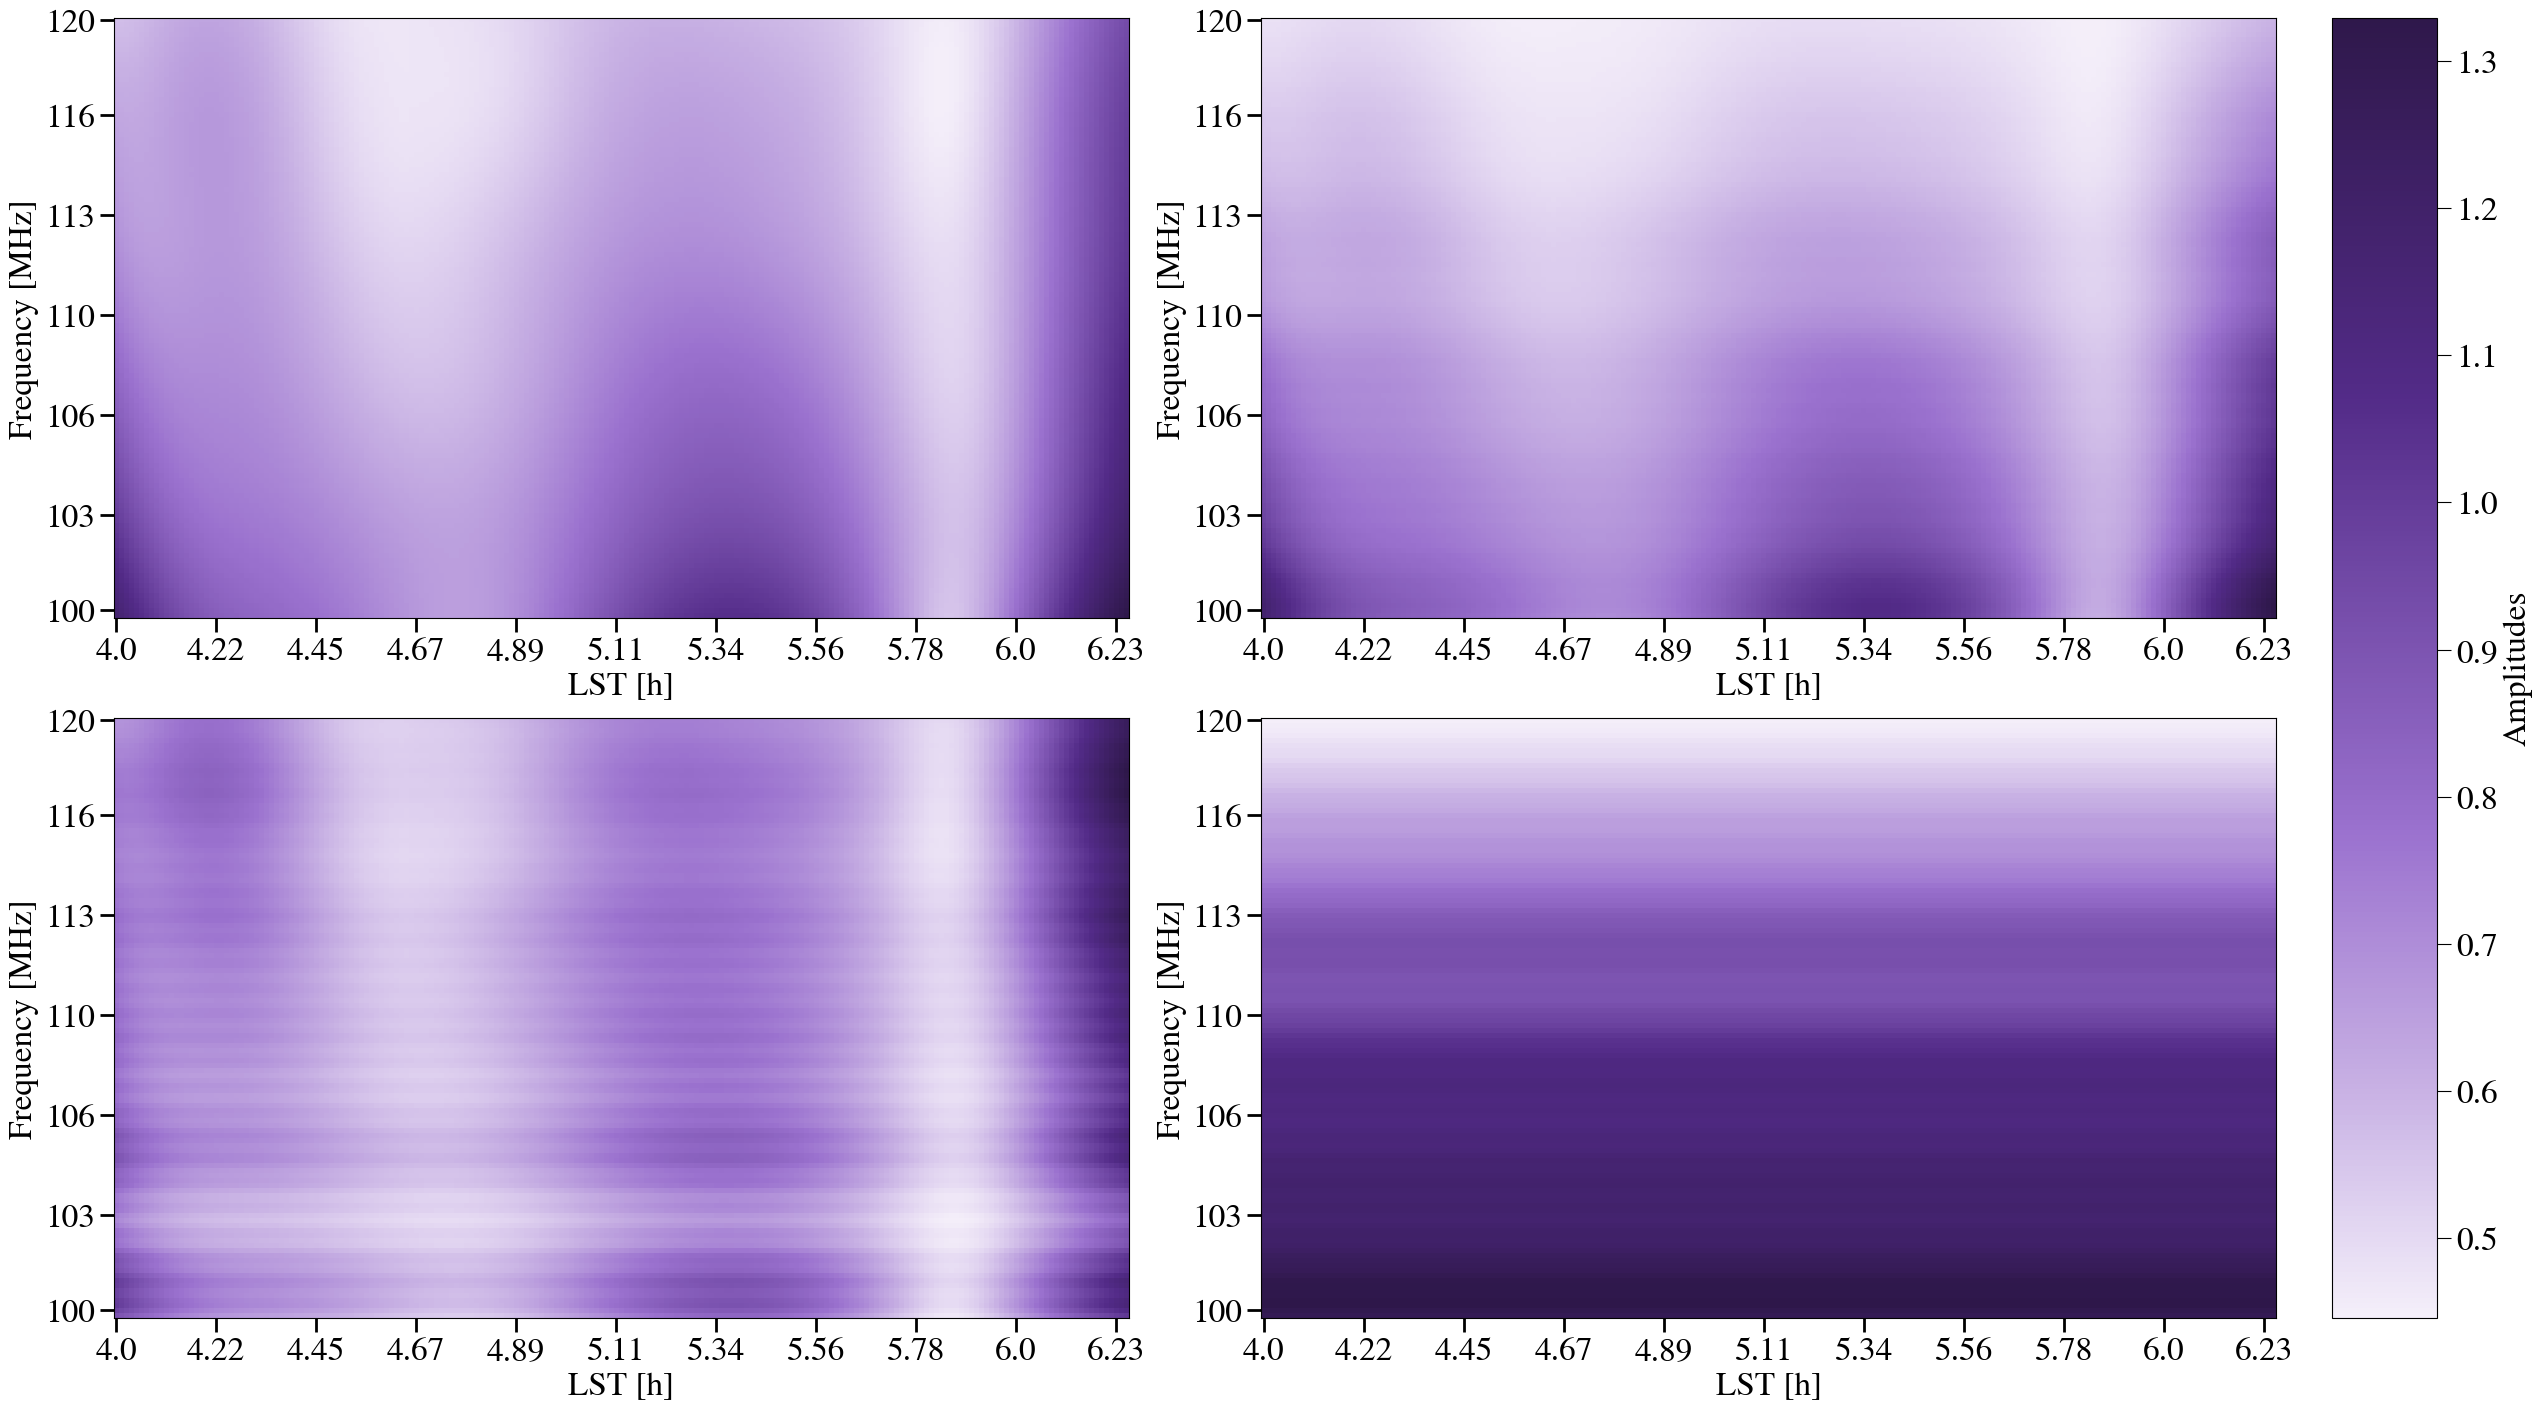

In [10]:
# fig, ax = plt.subplots(2,2,figsize=(28,22))
fig = plt.figure(figsize=(30.,20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.78, 0.65),   # leave room for labels + shared cbar
    nrows_ncols=(2, 2),
    axes_pad=1,
    cbar_mode="single",
    cbar_location="right",
    cbar_pad=0.4,
    label_mode="all",
    aspect=False,
)
data_arr=np.array([[clean_vis,vis_corr],[vis_corr-clean_vis,vis_corr/clean_vis]])
title_list=[['Simulated sky visibilities','Simulated visbilities with systematics'],['Systematics as additive component','Systematics as gain component']]
a=0
for i in range(2):
    for j in range(2):
        im=axs[a].imshow(np.abs(data_arr[i,j,:,:]).T,cmap=paper_map_purple,origin='lower')
        # ax[i,j].set_title(title_list[i][j],pad=15)
        axs[a].set_ylabel('Frequency [MHz]')
        axs[a].set_xlabel('LST [h]')
        axs[a].tick_params(direction='out', length=6, width=2, colors='black',size=10)
        a=a+1

cbar=axs.cbar_axes[0].colorbar(im,label='Amplitudes')
cbar.ax.tick_params(which='both', color='black', labelcolor='black',size=10)


for a in axs:
    a.set_yticks(xticklocs,labels=xticklabels_freqs)
    a.set_xticks(yticklocs,labels=yticklabels_times)
    
#NOTE: Axes switched and transpose of data posted for better view in the paper. 
# plt.savefig(fig_dir+'/'+'systematics_in_vis_space.pdf',bbox_inches='tight',dpi=300)

# Figure 2 is in the test notebook from hera_val

In [11]:
# fig = plt.figure(figsize=(30, 8), constrained_layout=True)
# gs  = fig.add_gridspec(nrows=1, ncols=4, width_ratios=[1, 1, 1, 0.04], wspace=0.08)
# plt.rcParams.update({'font.size': 30})

# ax0 = fig.add_subplot(gs[0, 0])
# ax1 = fig.add_subplot(gs[0, 1], sharex=ax0, sharey=ax0)
# ax2 = fig.add_subplot(gs[0, 2], sharex=ax0, sharey=ax0)
# cax = fig.add_subplot(gs[0, 3])  # colorbar axis

# bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
# vmax = np.log10(np.abs(vis_eor)).max()
# vmin = vmax - dynamic_range

# norm = Normalize(vmin=vmin, vmax=vmax)
# cmap = paper_map_pink

# eor_dlfr=plot_waterfalls(vis_eor, freqs_eor, lst_eor, windows='blackman-harris', fig=fig,ax=ax0, mode='log', 
#                 vmin=-3,vmax=5,cmap=paper_map_pink, dynamic_range=5, limit_drng='all',colorbar_flag=False,
#                 baseline=None, horizon_color='magenta',
#                 freq_window_kwargs=None, time_window_kwargs=None)
# ax0.text(0.95,0.07,'EoR',bbox=bbox,
#             transform=ax0.transAxes, horizontalalignment='right')

# fg_dlfr = plot_waterfalls(vis_sky, freqs_sky, lst_sky, windows='blackman-harris', mode='log', fig=fig,ax=ax1,
#                 vmin=-3,vmax=5,cmap=paper_map_pink, dynamic_range=5, limit_drng='all',colorbar_flag=False,
#                 baseline=None, horizon_color='magenta',
#                 freq_window_kwargs=None, time_window_kwargs=None)
# ax1.text(0.95,0.07,'EoR+FG',bbox=bbox,
#             transform=ax1.transAxes, horizontalalignment='right')

# corr_dlfr=plot_waterfalls(vis_corr, freqs_corr, lst_corr, windows='blackman-harris', mode='log', fig=fig,ax=ax2,
#                 vmin=-3,vmax=5,cmap=paper_map_pink, dynamic_range=5, limit_drng='all',colorbar_flag=False,
#                 baseline=None, horizon_color='magenta',
#                 freq_window_kwargs=None, time_window_kwargs=None)

# ax2.text(0.95,0.07,'EoR+FG+Sys',bbox=bbox,
#             transform=ax2.transAxes, horizontalalignment='right')

# sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
# cbar = fig.colorbar(sm, cax=cax)
# cbar.set_label(r"$\log_{10}|\tilde{V}(\tau, f)|$ [Jy Hz s]")     

# # plt.savefig(fig_dir+'/'+'data_in_dlfr_space.pdf',bbox_inches='tight',dpi=300)

# Figure 3: Plotting the different systematic locations in DL FR space

## Loading data

In [12]:
'''Loading Data from uvh5'''
uvd=UVData()
uvd.read('/nvme2/scratch/sohini/hydra-pspec-systematic/res/test_data/vis-eor.uvh5')
uvd=form_pseudo_stokes_vis(uvd)
antpairpols=uvd.get_antpairpols()
vis_eor=uvd.get_data(antpairpols[0], force_copy=True) #EoR test
freqs_=uvd.freq_array
freqs_eor=freqs_.reshape(freqs_.shape[0],) #[0]
lst_eor=np.unique(uvd.lst_array)

uvd=UVData()
uvd.read('/nvme2/scratch/sohini/hydra-pspec-systematic/res/test_data/vis-ptsrc-gsm.uvh5')
uvd=form_pseudo_stokes_vis(uvd)
antpairpols=uvd.get_antpairpols()
fg_true=uvd.get_data(antpairpols[0], force_copy=True) #EoR test
freqs_fg=freqs_.reshape(freqs_.shape[0],) #[0]
lst_fg=np.unique(uvd.lst_array)

uvd=UVData()
uvd.read('/nvme2/scratch/sohini/hydra-pspec-systematic/res/vis_corrupted_test.uvh5')
uvd=form_pseudo_stokes_vis(uvd)
antpairpols=uvd.get_antpairpols()
vis_corr=uvd.get_data(antpairpols[0], force_copy=True) #EoR test
freqs_corr=freqs_.reshape(freqs_.shape[0],) #[0]
lst_corr=np.unique(uvd.lst_array)

uvd=UVData()
uvd.read('/nvme2/scratch/sohini/hydra-pspec-systematic/res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd=form_pseudo_stokes_vis(uvd)
antpairpols=uvd.get_antpairpols()
vis_sky=uvd.get_data(antpairpols[0], force_copy=True) #EoR test
freqs_sky=freqs_.reshape(freqs_.shape[0],) #[0]
lst_sky=np.unique(uvd.lst_array)

noise=np.load('/nvme2/scratch/sohini/hydra-pspec-systematic/res/test_data/noise.npy')

## Plot

3 0
4 0
5 0
6 0
10 0
11 0
12 0
13 0
3 20
4 20
5 20
6 20
20 20
21 20
22 21
23 21


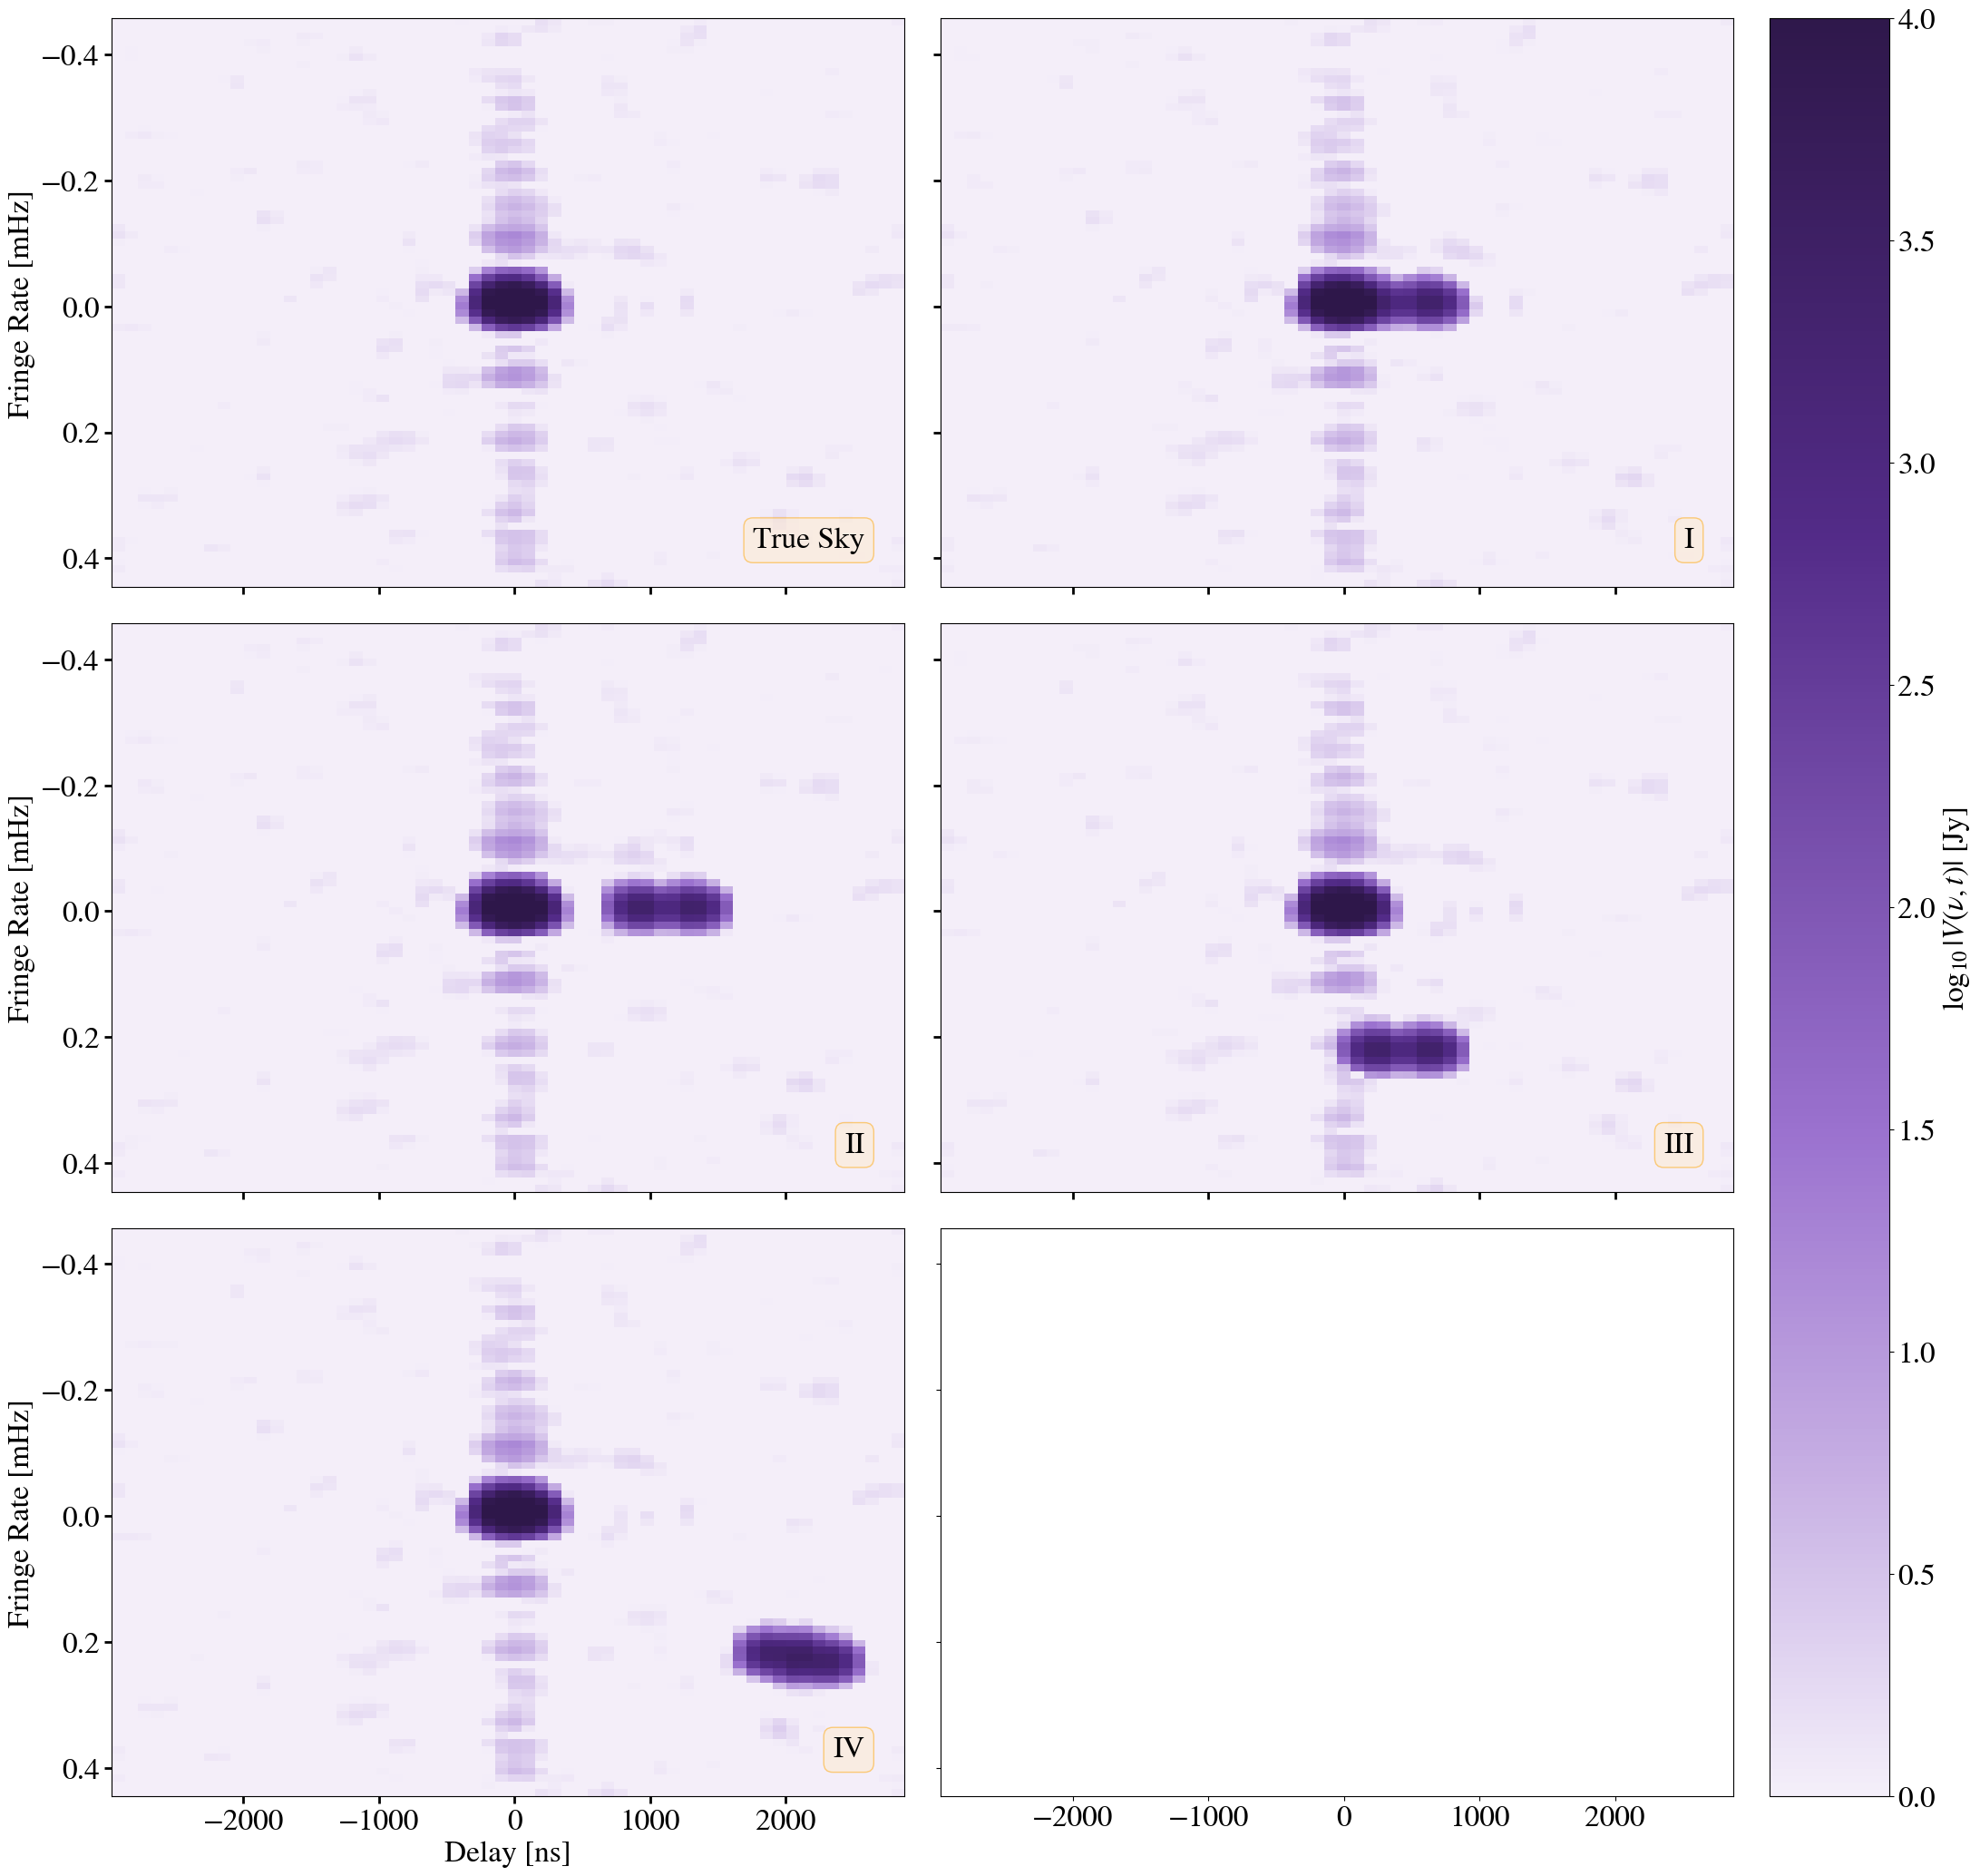

In [13]:
# fig,axs = plt.subplots(2,2,layout="constrained",figsize=(20,20))
fig = plt.figure(figsize=(20.,20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),   # leave room for labels + shared cbar
    nrows_ncols=(3, 2),
    axes_pad=0.4,
    cbar_mode="single",
    cbar_location="right",
    cbar_pad=0.4,
    label_mode="L",
    aspect=False,
)
run_version_arr = ['low_dl_fr_0','high_dl_fr_0','low_dl_fr_20','high_dl_high_fr']

nm_list_arr = [
            [(3,0),(4,0),(5,0),(6,0)],
            [(10,0), (11,0), (12,0), (13,0)],
            [(3,20),(4,20),(5,20),(6,20)],
            [(20,20),(21,20),(22,21),(23,21)]
            ]

bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
i=0

eor_true=np.load(result_dir+run_version_arr[0]+'/eor_true.npy')[:Ntimes,:Nfreqs]
fg_true=np.load(parent_dir+'res/npy_data/fg_true.npy')[:Ntimes,:Nfreqs]
ps_true = calc_ps(eor_true[:Ntimes,:Nfreqs])
data_true = eor_true+ fg_true

data_true_dlfr = data_dly_fr(data_true,freqs*1e6, lsts, windows='blackman-harris')

_=plot_waterfalls_from_dlfr(data_true_dlfr, freqs*1e6, lsts, fig=fig,ax=axs[0], mode='log', 
                vmin=0,vmax=4,cmap=paper_map_purple, dynamic_range=5, limit_drng='all',
                baseline=None, horizon_color='magenta',colorbar_flag=False)
axs[0].text(0.95,0.07,'True Sky',bbox=bbox,
            transform=axs[0].transAxes, horizontalalignment='right')

fig_labels = ['I','II','III','IV']
for run_version in run_version_arr:
    sys_modes_operator = sys_modes(freqs_Hz=freqs*1e6, 
                                    times_sec=lsts * 24./(2.*np.pi) * 3600., 
                                    modes=nm_list_arr[i])
    sys_model_true= (1+sys_modes_operator @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
    total_data_true = sys_model_true * data_true
    total_data_dlfr = data_dly_fr(total_data_true,freqs*1e6, lsts, windows='blackman-harris')
    plot_op=plot_waterfalls_from_dlfr(total_data_dlfr, freqs*1e6, lsts, fig=fig,ax=axs[i+1], mode='log', 
                vmin=0,vmax=4,cmap=paper_map_purple, dynamic_range=5, limit_drng='all', colorbar_flag=False,
                baseline=None, horizon_color='magenta')
    axs[i+1].text(0.95,0.07,fig_labels[i],bbox=bbox,
            transform=axs[i+1].transAxes, horizontalalignment='right')
    i=i+1
vis_label= r"$\log_{10}|V(\nu, t)|$ [Jy]"
axs.cbar_axes[0].colorbar(plot_op, label=vis_label)
# plt.savefig(fig_dir+'/'+'test_cases_in_dlfr.pdf',bbox_inches='tight',dpi=300)

# Case III data analysis

hydra-pspec-systematic/paper_plots/100k_runs/low_dl_fr_20 //
100k iterations //
1e-7 bound //
0.0004 noise //
True sys start 

##  Loading data

In [25]:
'''Loading Data'''

v = 3  # Run versino array index, change this to load results for different cases
fg_true=np.load(result_dir+run_version_arr[v]+'/fg_true.npy')

# fg_true=np.load(result_dir+'/fg_true_fit.npy') #For FG fit
fgmodes=np.load(result_dir+run_version_arr[v]+'/fgmodes.npy')
fg_amps_gcr = np.load(result_dir+run_version_arr[v]+'/fg-amps.npy')
eor_true=np.load(result_dir+run_version_arr[v]+'/eor_true.npy')
eor_gcr = np.load(result_dir+run_version_arr[v]+'/gcr-eor.npy')
ps_sample = np.load(result_dir+run_version_arr[v]+'/dps-eor.npy')
ln_post = np.load(result_dir+run_version_arr[v]+'/ln-post.npy')

b_sys_gcr = np.load(result_dir+run_version_arr[v]+'/b-sys.npy')
sys_model_true = np.load(result_dir+run_version_arr[v]+'/gain_true.npy')
delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs,Ntimes]).T

sky_true = eor_true + fg_true
data_true = np.load(result_dir+run_version_arr[v]+'/data_true.npy')

'''Getting power spectra'''
ps_fg=np.empty(ps_sample.shape)
ps_sys=np.empty(ps_sample.shape)
ps_del_g=np.empty(ps_sample.shape)
ps_data=np.empty(ps_sample.shape)

for i in tqdm(range(len(ps_sample))):
    sys_model = (sys_modes_operator @ b_sys_gcr[i,:]).reshape([Nfreqs,Ntimes]).T
    data_model = (1+sys_model) * (eor_gcr[i,:,:] + (fgmodes @ fg_amps_gcr[i,:].T).T)
    ps_data[i] = calc_ps(data_model)
    ps_fg[i] = calc_ps((fgmodes[:,:Nfgmodes] @ fg_amps_gcr[i,:].T).T)
    ps_sys[i] = calc_ps(1+sys_model)
    ps_del_g[i] = calc_ps(sys_model)

eor_pspec_avg = np.mean(ps_sample,axis=0)
fg_pspec_avg = np.mean(ps_fg,axis=0)
sys_pspec_avg = np.mean(ps_sys,axis=0)
data_pspec_avg = np.mean(ps_data,axis=0)
delg_pspec_avg = np.mean(ps_del_g,axis=0)

eor_pspec_true = calc_ps(eor_true)
fg_pspec_true =  calc_ps(fg_true)
sys_pspec_true = calc_ps(sys_model_true)
n_pspec = calc_ps(n.T)
data_pspec_true = calc_ps(data_true)

b_sys_mean = np.mean(b_sys_gcr,axis=0)

'''Getting some DLFR visibilities'''
sky_true_dlfr=data_dly_fr(sky_true,freqs*1e6, lsts, windows='blackman-harris')
sys_model_true_dlfr = data_dly_fr(sys_model_true,freqs*1e6, lsts, windows='blackman-harris')
delta_g_dlfr_true = data_dly_fr(delta_g_true,freqs*1e6, lsts, windows='blackman-harris')
data_true_dlfr = data_dly_fr(data_true,freqs*1e6, lsts, windows='blackman-harris')

100%|██████████| 100000/100000 [01:06<00:00, 1512.07it/s]


## Getting sample-by-sample models

In [26]:
'''Vis Arrays'''
fg_vis_arr=np.empty([fg_amps_gcr.shape[0],Ntimes,Nfreqs],dtype='complex')
delta_g_arr = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')

'''DLFR Arrays'''
eor_dlfr_arr=np.empty(eor_gcr.shape,dtype='complex')
sky_dlfr_arr=np.empty(eor_gcr.shape,dtype='complex')
delta_g_dlfr_arr = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
sys_model_dlfr_arr = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')


print("Foregrounds...")
for i in tqdm(range(fg_amps_gcr.shape[0])):
    fg_vis_arr[i,:,:] = (fgmodes @ fg_amps_gcr[i,:].T).T

print("Sky DLFR...")
for i in tqdm(range(len(eor_gcr))):
    eor_dlfr_arr[i,:,:]=data_dly_fr(eor_gcr[i,:,:],freqs*1e6, lsts, windows='blackman-harris',)
    sky_dlfr_arr[i,:,:] = data_dly_fr(eor_gcr[i,:,:]+fg_vis_arr[i,:,:],freqs*1e6, lsts, windows='blackman-harris',)

print("Systematics...")
for i in tqdm(range(Niter)):
    delta_g_arr[i,:,:] = (sys_modes_operator @ b_sys_gcr[i,:]).reshape([Nfreqs,Ntimes]).T
    delta_g_dlfr_arr[i,:,:] = data_dly_fr(delta_g_arr[i,:,:],freqs*1e6, lsts, windows='blackman-harris')
    sys_model_dlfr_arr[i,:,:] = data_dly_fr(1+delta_g_arr[i,:,:],freqs*1e6, lsts, windows='blackman-harris')

delta_g_dlfr_mean = delta_g_dlfr_arr.mean(axis=0)
delta_g_dlfr_std = np.std(delta_g_dlfr_arr,axis=0)
delta_g_mean = delta_g_arr.mean(axis=0)
delta_g_std = np.std(delta_g_arr, axis=0)
sys_model_dlfr_mean   = sys_model_dlfr_arr.mean(axis=0)

mean_sky_dlfr  = sky_dlfr_arr.mean(axis=0)
mean_eor_dlfr = eor_dlfr_arr.mean(axis=0)


Foregrounds...


  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [00:02<00:00, 39621.89it/s]


Sky DLFR...


100%|██████████| 100000/100000 [00:28<00:00, 3454.66it/s]


Systematics...


100%|██████████| 100000/100000 [00:48<00:00, 2082.11it/s]


# Figure 4: data vs sky

##  New plot

3 0
4 0
5 0
6 0
Foregrounds...


100%|██████████| 100000/100000 [00:02<00:00, 39245.27it/s]


Sky DLFR...


 39%|███▊      | 38696/100000 [00:11<00:17, 3454.30it/s]


KeyboardInterrupt: 

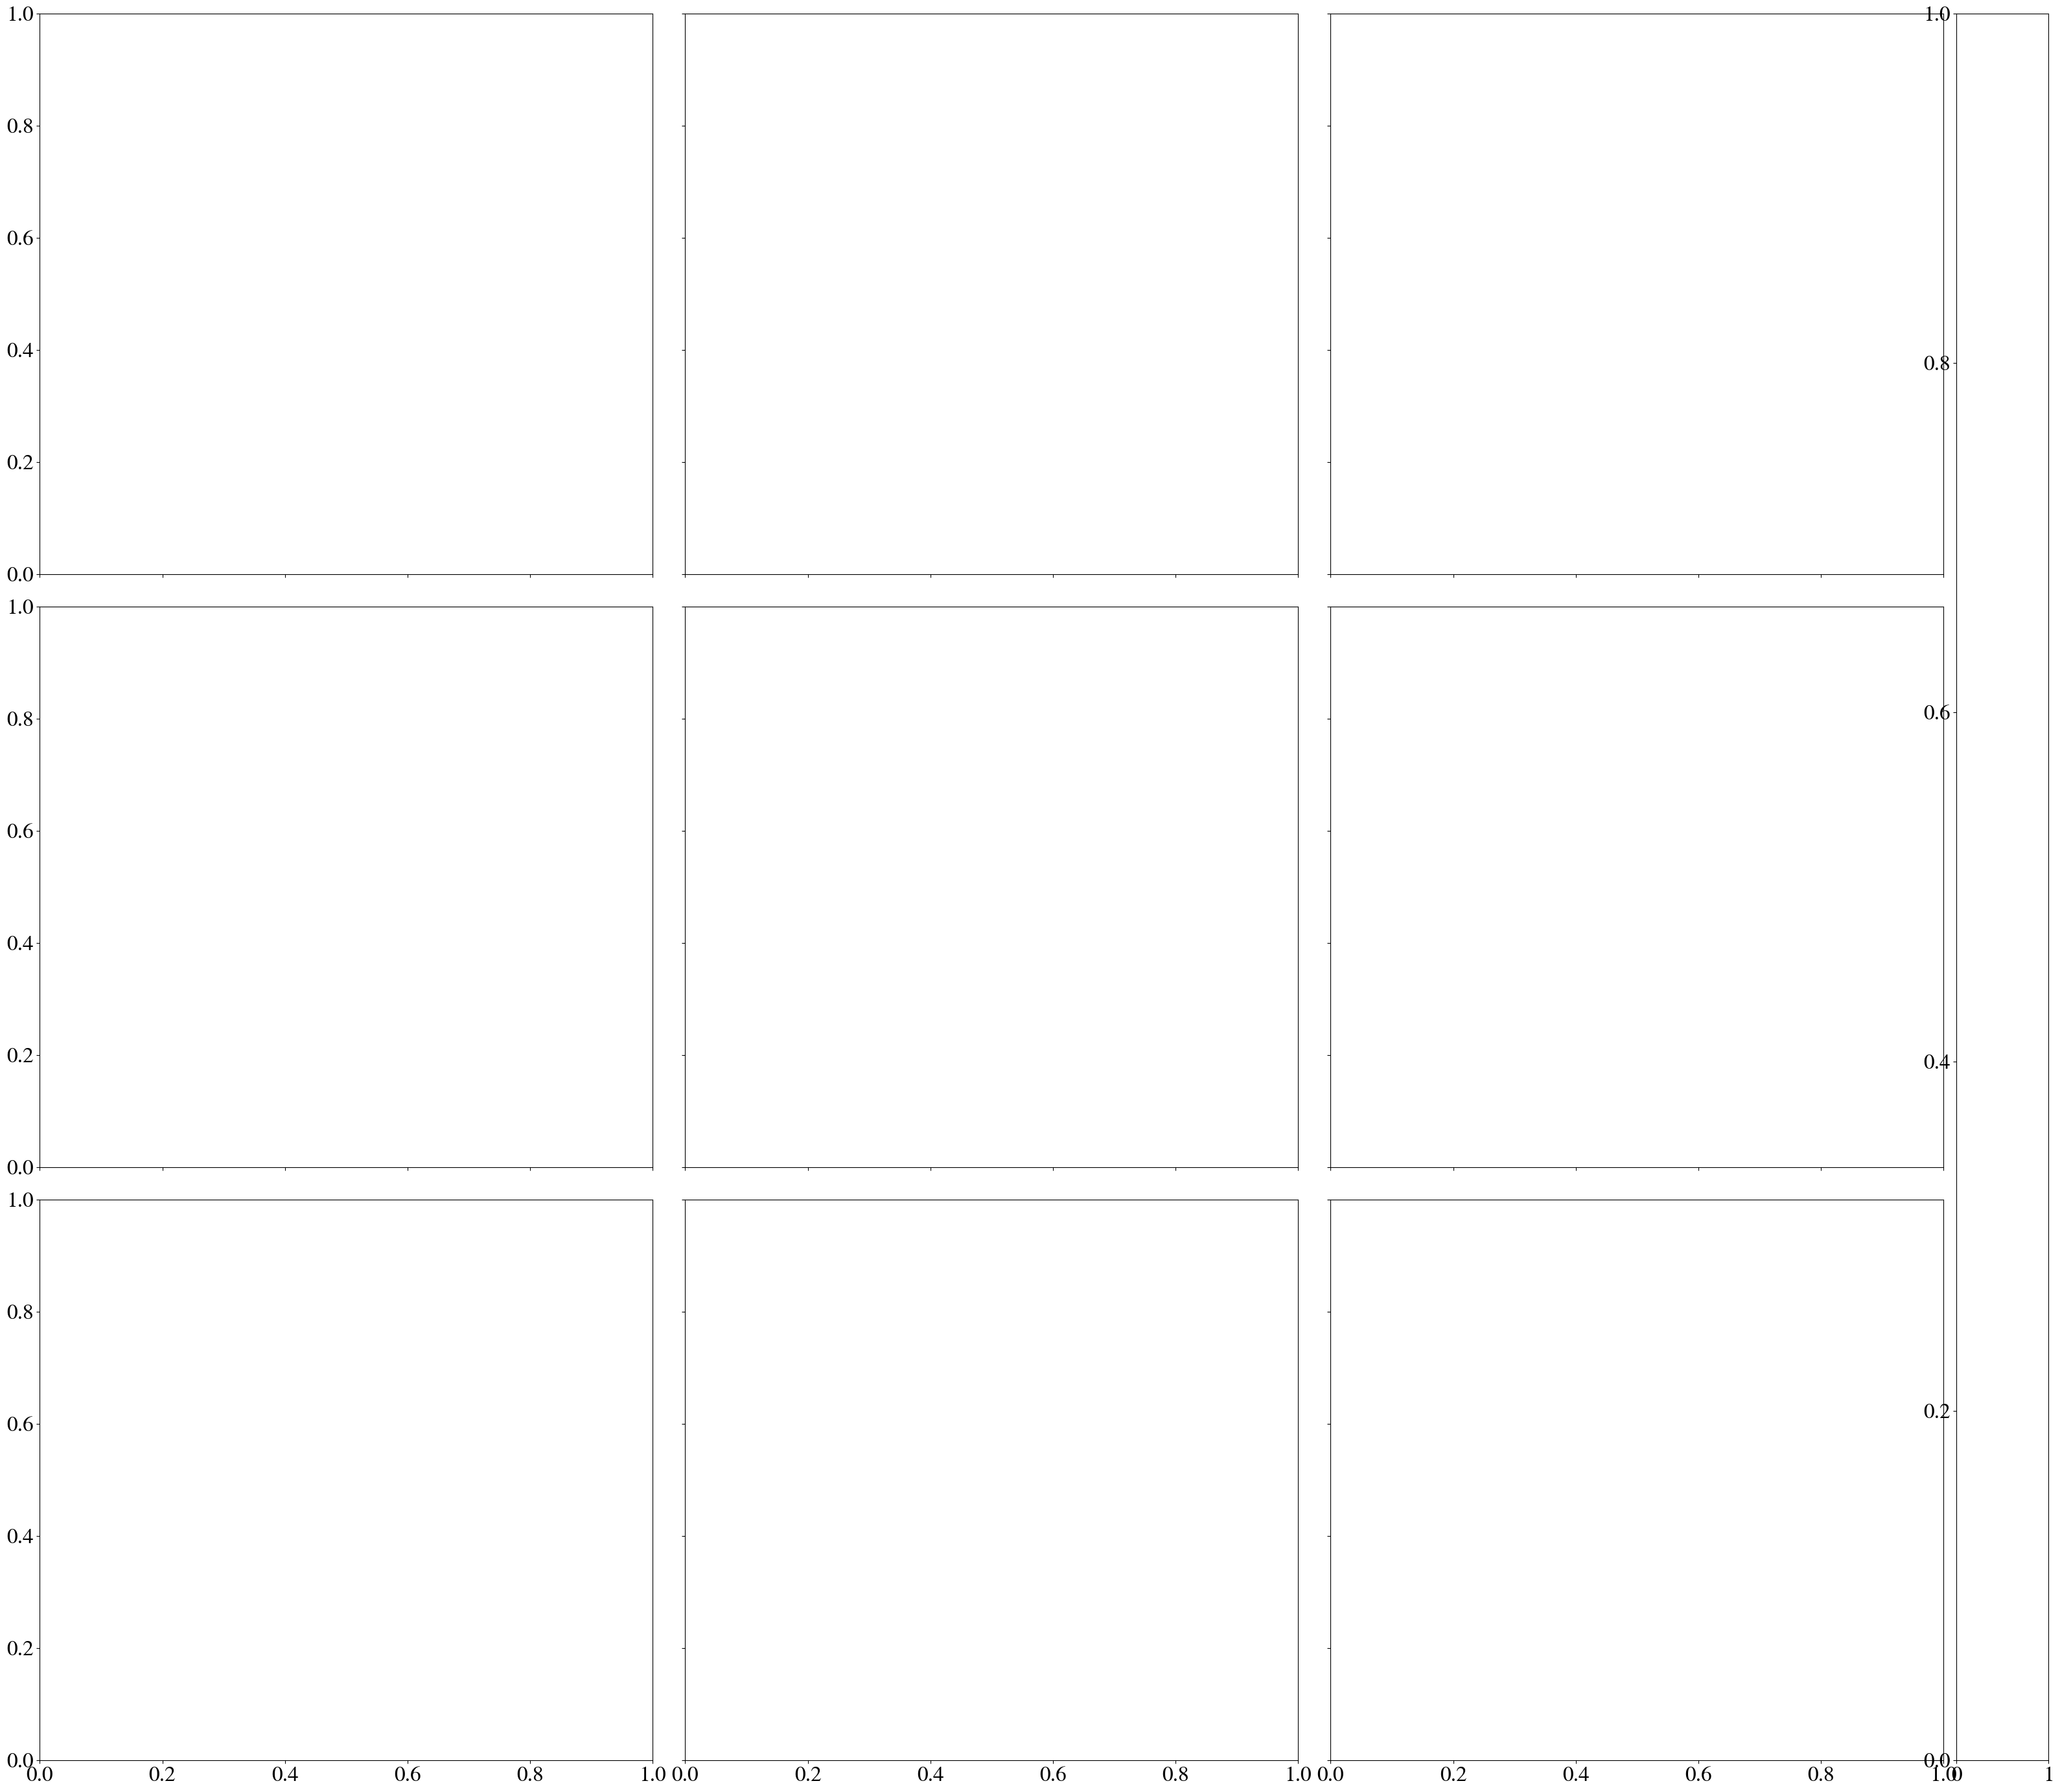

In [17]:
fig = plt.figure(figsize=(40,35))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(3, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="5%",
    cbar_pad=0.2,
    aspect=False
)

c=0

for a in range(3):
    '''Loading Data'''
    sys_modes_operator_case1 = sys_modes(freqs_Hz=freqs*1e6, 
                                        times_sec=lsts * 24./(2.*np.pi) * 3600., 
                                        modes=nm_list_arr[a])
    
    fg_amps_gcr_case1 = np.load(result_dir+run_version_arr[a]+'/fg-amps.npy')
    eor_gcr_case1 = np.load(result_dir+run_version_arr[a]+'/gcr-eor.npy')

    b_sys_gcr_case1 = np.load(result_dir+run_version_arr[a]+'/b-sys.npy')
    sys_model_true_case1 = np.load(result_dir+run_version_arr[a]+'/gain_true.npy')
    delta_g_true_case1 = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs,Ntimes]).T

    data_true_case1 = np.load(result_dir+run_version_arr[a]+'/data_true.npy')

    b_sys_mean_case1= np.mean(b_sys_gcr_case1,axis=0)

    
    '''Getting some DLFR visibilities'''

    sys_model_true_dlfr_case1 = data_dly_fr(sys_model_true_case1,freqs*1e6, lsts, windows='blackman-harris')
    delta_g_dlfr_true_case1 = data_dly_fr(delta_g_true_case1,freqs*1e6, lsts, windows='blackman-harris')
    data_true_dlfr_case1 = data_dly_fr(data_true_case1,freqs*1e6, lsts, windows='blackman-harris')

    '''Vis Arrays'''
    fg_vis_arr_case1=np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    delta_g_arr_case1 = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')

    '''DLFR Arrays'''
    eor_dlfr_arr_case1=np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    sky_dlfr_arr_case1=np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    delta_g_dlfr_arr_case1 = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    sys_model_dlfr_arr_case1 = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')


    print("Foregrounds...")
    for i in tqdm(range(Niter)):
        fg_vis_arr_case1[i,:,:] = (fgmodes @ fg_amps_gcr_case1[i,:].T).T

    print("Sky DLFR...")
    for i in tqdm(range(Niter)):
        eor_dlfr_arr_case1[i,:,:]=data_dly_fr(eor_gcr_case1[i,:,:],freqs*1e6, lsts, windows='blackman-harris',)
        sky_dlfr_arr_case1[i,:,:] = data_dly_fr(eor_gcr_case1[i,:,:]+fg_vis_arr_case1[i,:,:],freqs*1e6, lsts, windows='blackman-harris',)

    print("Systematics...")
    for i in tqdm(range(Niter)):
        delta_g_arr_case1[i,:,:] = (sys_modes_operator_case1 @ b_sys_gcr_case1[i,:]).reshape([Nfreqs,Ntimes]).T
        delta_g_dlfr_arr_case1[i,:,:] = data_dly_fr(delta_g_arr_case1[i,:,:],freqs*1e6, lsts, windows='blackman-harris')
        sys_model_dlfr_arr_case1[i,:,:] = data_dly_fr(1+delta_g_arr_case1[i,:,:],freqs*1e6, lsts, windows='blackman-harris')

    delta_g_dlfr_mean_case1 = delta_g_dlfr_arr_case1.mean(axis=0)
    delta_g_dlfr_std_case1 = np.std(delta_g_dlfr_arr_case1,axis=0)
    delta_g_mean_case1 = delta_g_arr_case1.mean(axis=0)
    delta_g_std_case1 = np.std(delta_g_arr_case1, axis=0)
    sys_model_dlfr_mean_case1   = sys_model_dlfr_arr_case1.mean(axis=0)

    mean_sky_dlfr_case1  = sky_dlfr_arr_case1.mean(axis=0)
    mean_eor_dlfr_case1 = eor_dlfr_arr_case1.mean(axis=0)

    
    im0 = plot_waterfalls_from_dlfr(
    data_true_dlfr_case1, freqs*1e6, lsts,
    fig=fig, ax=ax[c], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta'
    )
    c=c+1
    im1 = plot_waterfalls_from_dlfr(
        mean_sky_dlfr_case1, freqs*1e6, lsts,
        fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta'
    )
    c=c+1
    im2 = plot_waterfalls_from_dlfr(
        delta_g_dlfr_mean_case1, freqs*1e6, lsts,
        fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta'
    )
    c=c+1

fig_labels=['I','I','I','II','II','II','III','III','III']
fig_titles=['Data','Sky Mean','Systematics Mean']
i=0
for a in ax:
    a.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=30)
    a.set_xlabel('Delays [ns]', fontsize=40)
    a.set_ylabel('Fringe Rate [mHz]', fontsize=40)
    a.text(0.95,0.07,fig_labels[i],bbox=bbox,
            transform=a.transAxes, horizontalalignment='right')
    i=i+1

i=0
for a in ax[:3]:
        a.set_title(fig_titles[i], fontsize=40, pad=15)
        i=i+1
vis_label = r"$\log_{10}|V(\nu, t)|$ [Jy]"
cbar = ax.cbar_axes[0].colorbar(im2)
cbar.set_label(vis_label, size=40)
cbar.ax.tick_params(labelsize=30)
# plt.savefig(fig_dir+'/data_vs_sky_2.pdf',bbox_inches='tight',dpi=300)

## Old plot

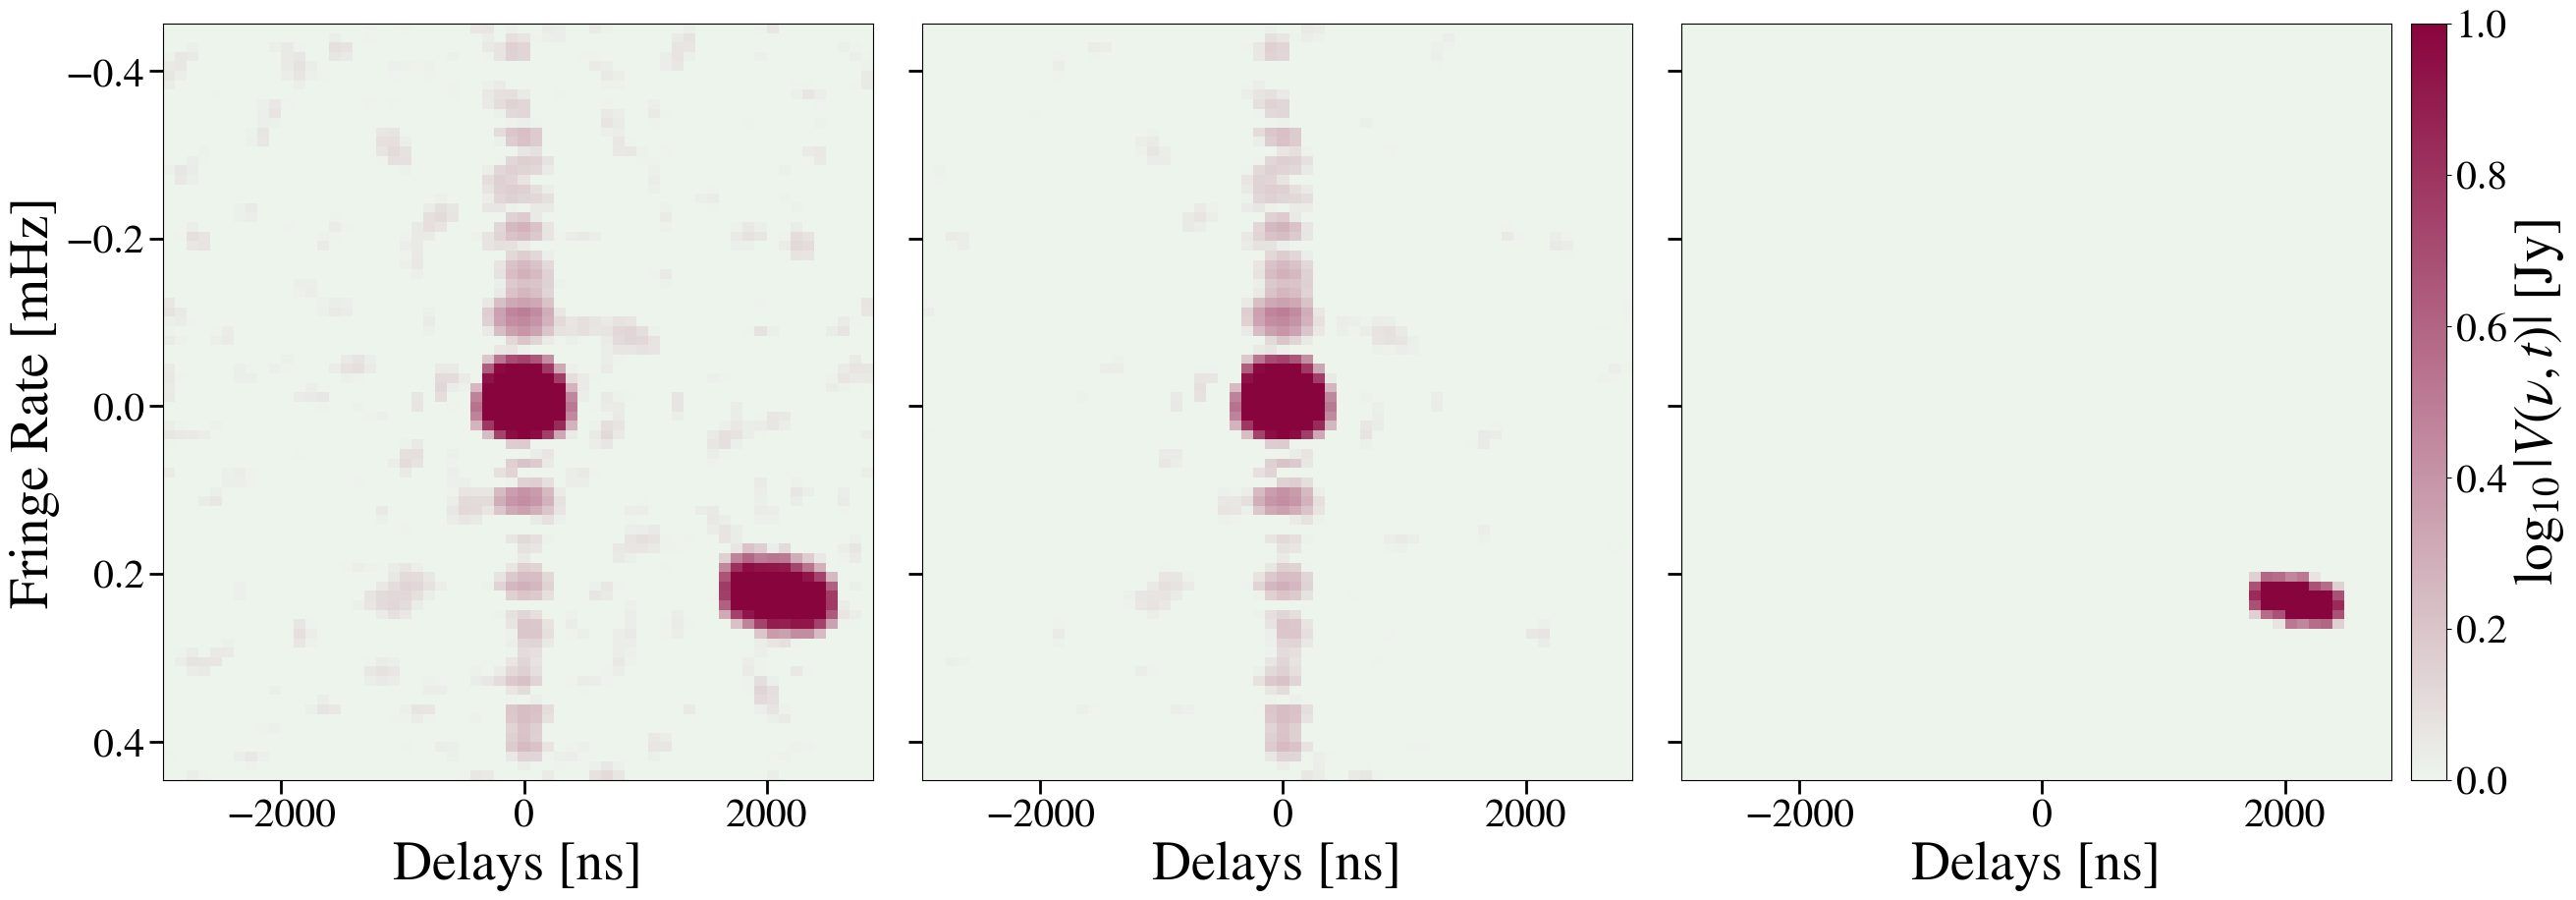

In [27]:
# plt.rcParams.update({'font.size': 60})
# --- prep data (your existing calls) ---

fig = plt.figure(figsize=(30,10))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="5%",
    cbar_pad=0.2,
    aspect=False
)


im0 = plot_waterfalls_from_dlfr(
    data_true_dlfr, freqs*1e6, lsts,
    fig=fig, ax=ax[0], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta'
)

im1 = plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs*1e6, lsts,
    fig=fig, ax=ax[1], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta'
)

im2 = plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs*1e6, lsts,
    fig=fig, ax=ax[2], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta'
)

for i in range(3):
    ax[i].tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=30)
    ax[i].set_xlabel('Delays [ns]', fontsize=40)
    ax[i].set_ylabel('Fringe Rate [mHz]', fontsize=40)
vis_label = r"$\log_{10}|V(\nu, t)|$ [Jy]"
cbar = ax.cbar_axes[0].colorbar(im2)
cbar.set_label(vis_label, size=40)
cbar.ax.tick_params(labelsize=30)
# plt.savefig(fig_dir+'/data_vs_sky.pdf',bbox_inches='tight',dpi=300)

# Figure 5: Result Waterfalls

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

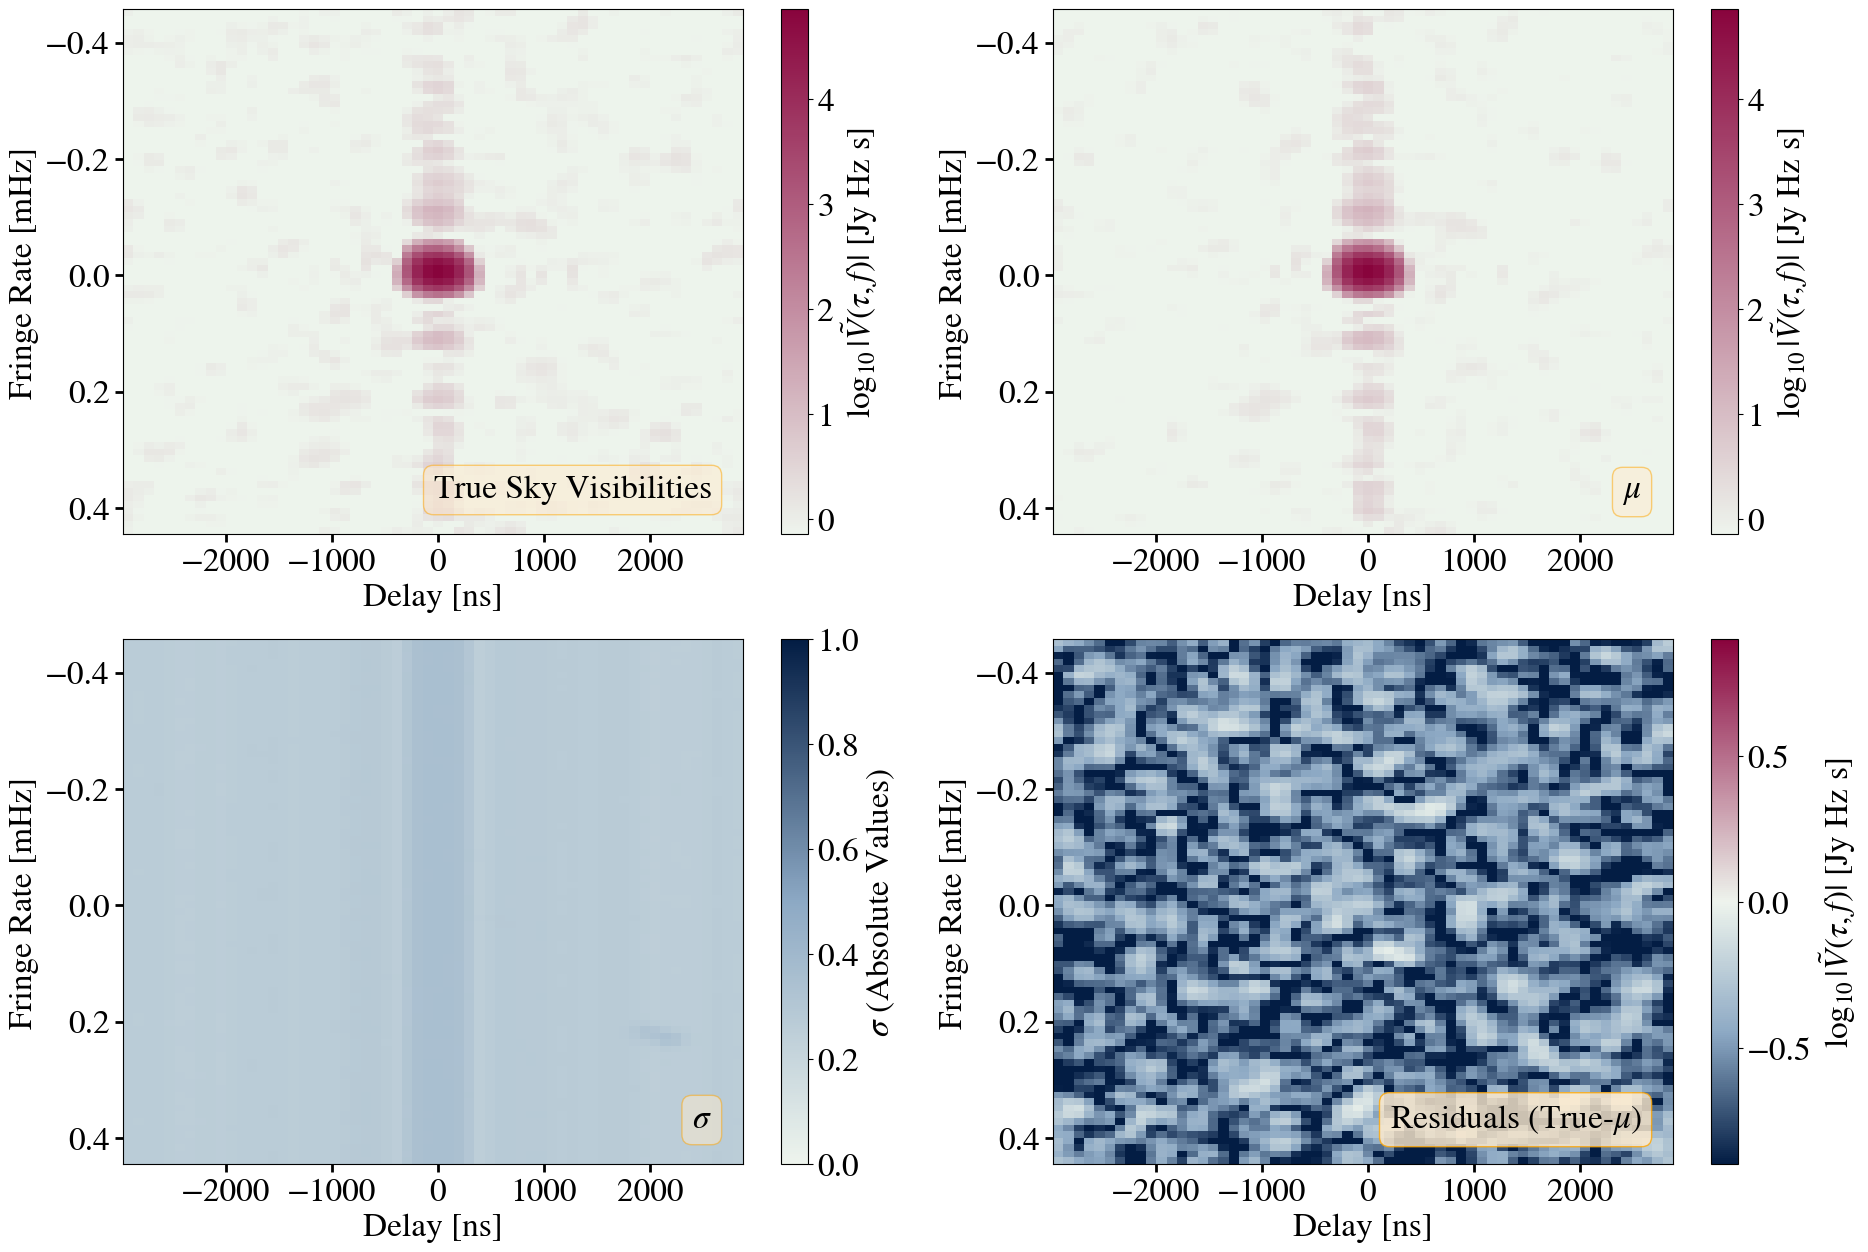

In [28]:
fig,axs=plt.subplots(2,2,figsize=(22,15))

'''True Sky'''
im1=plot_waterfalls_from_dlfr(sky_true_dlfr, freqs*1e6, lsts, fig=fig,ax=axs.flatten()[0], mode='log', 
                vmin=None,vmax=None,cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta')
axs.flatten()[0].text(0.95,0.07,"True Sky Visibilities", bbox=bbox,
            transform=axs.flatten()[0].transAxes, horizontalalignment='right')

'''Mean Sky'''
im1=plot_waterfalls_from_dlfr(mean_sky_dlfr, freqs*1e6, lsts, fig=fig,ax=axs.flatten()[1], mode='log', 
                vmin=None,vmax=None,cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta')
axs.flatten()[1].text(0.95,0.07,r'$\mu$', bbox=bbox,
            transform=axs.flatten()[1].transAxes, horizontalalignment='right')

'''STD Sky'''
im2=plot_waterfalls_from_dlfr(np.std(sky_dlfr_arr,axis=0), freqs*1e6, lsts, fig=fig,ax=axs.flatten()[2], mode='abs', 
                vmin=0,vmax=1,cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta',cbar_label=r'$\sigma$ (Absolute Values)')
axs.flatten()[2].text(0.95,0.07,r'$\sigma$', bbox=bbox,
            transform=axs.flatten()[2].transAxes, horizontalalignment='right')

'''True - Mean'''
im3=plot_waterfalls_from_dlfr(sky_true_dlfr - mean_sky_dlfr, freqs*1e6, lsts, fig=fig,ax=axs.flatten()[3], mode='log', 
                vmin=-0.9,vmax=0.9,cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta')
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)
axs.flatten()[3].text(0.95,0.07,"Residuals (True-"+r'$\mu$'+")", bbox=bbox_res,
            transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir+'/result_waterfalls.pdf',bbox_inches='tight',dpi=300)

# Figure 6: Systematics result waterfalls

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

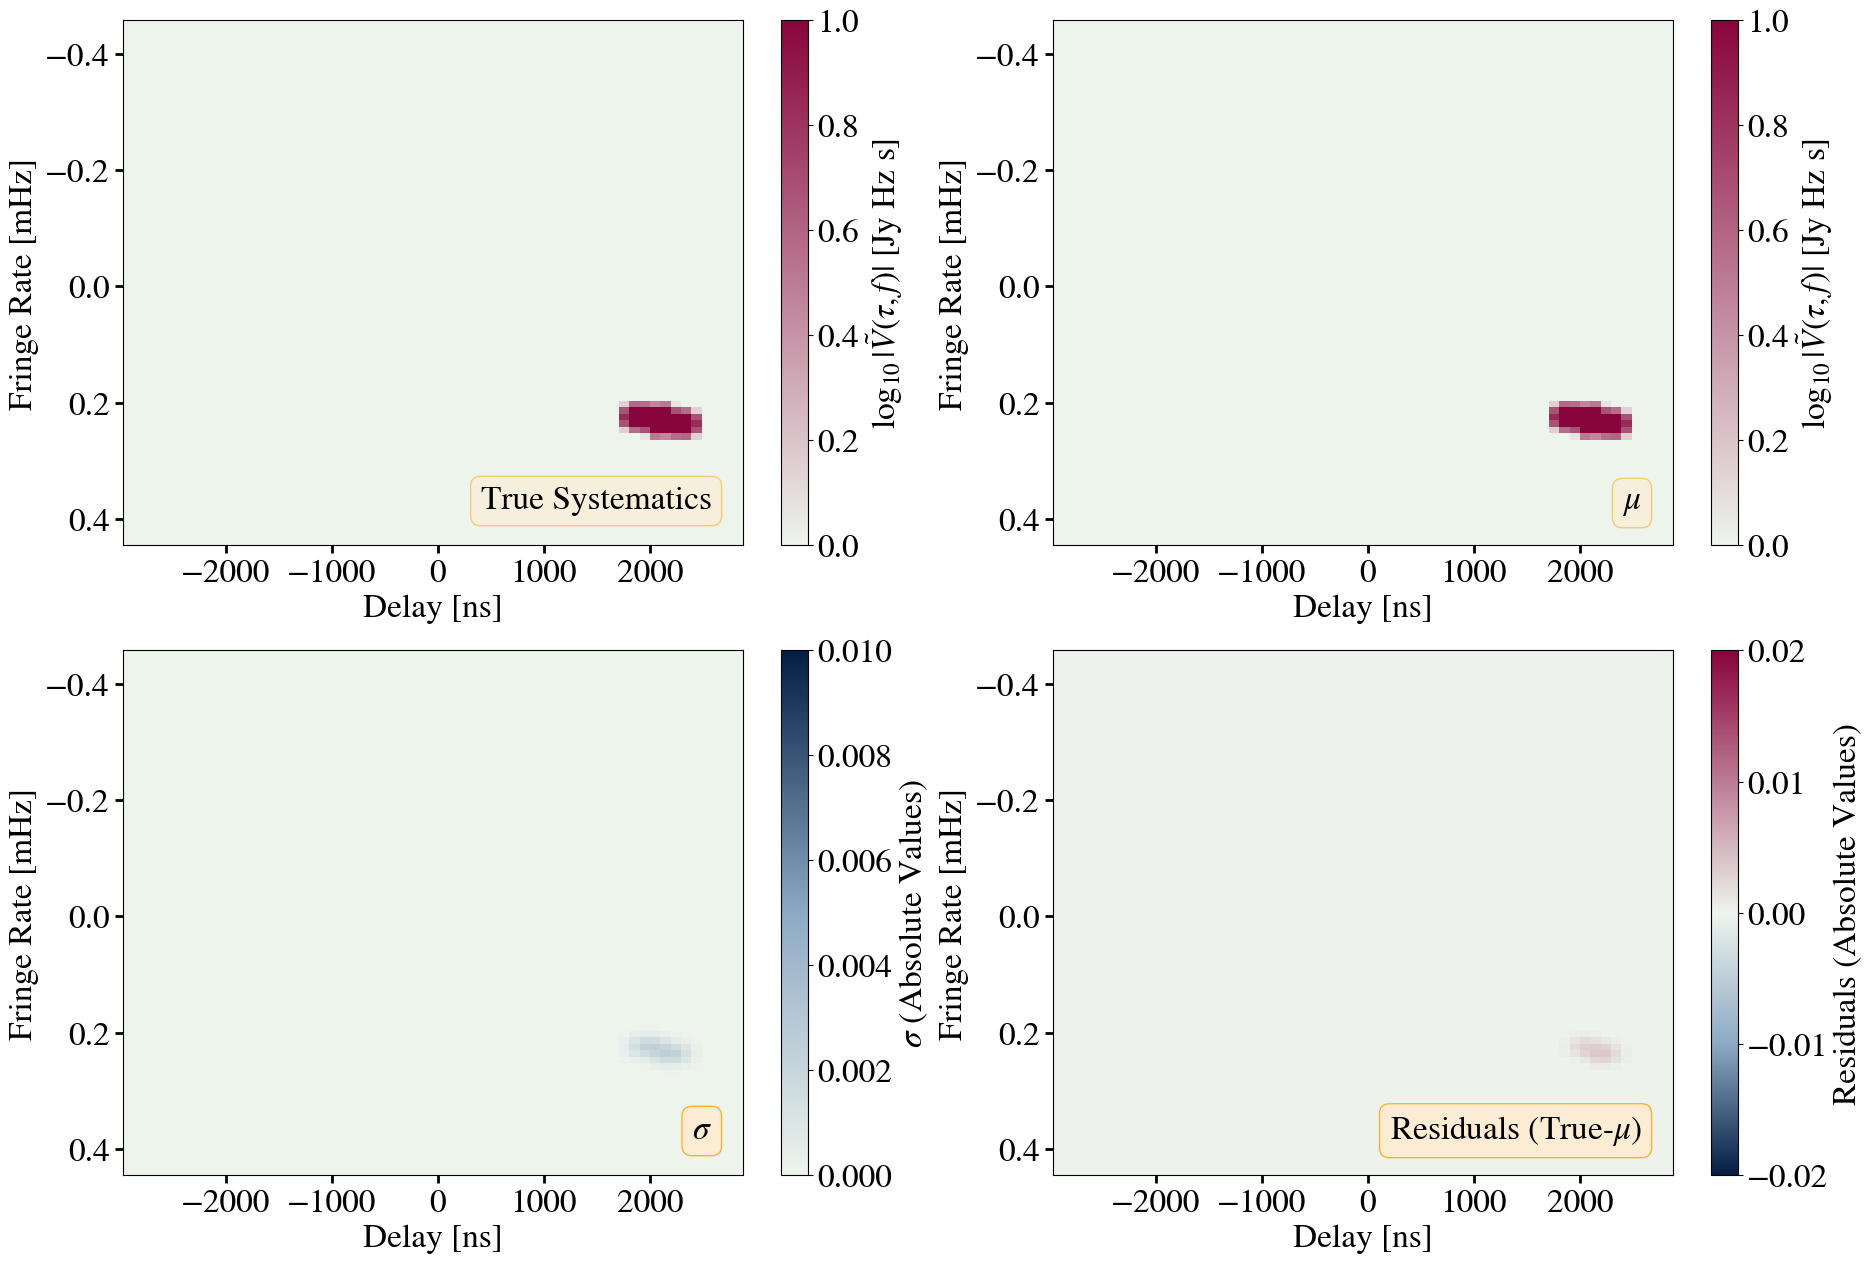

In [29]:
fig,axs=plt.subplots(2,2,figsize=(22,15))

'''True delta_g'''
im1=plot_waterfalls_from_dlfr(delta_g_dlfr_true, freqs*1e6, lsts, fig=fig,ax=axs.flatten()[0], mode='log', 
                vmin=0,vmax=1,cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta')
axs.flatten()[0].text(0.95,0.07,"True Systematics", bbox=bbox,
            transform=axs.flatten()[0].transAxes, horizontalalignment='right')
'''Mean delta_g'''
im1=plot_waterfalls_from_dlfr(delta_g_dlfr_mean, freqs*1e6, lsts, fig=fig,ax=axs.flatten()[1], mode='log', 
                vmin=0,vmax=1,cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta')
axs.flatten()[1].text(0.95,0.07,r'$\mu$', bbox=bbox,
            transform=axs.flatten()[1].transAxes, horizontalalignment='right')

'''STD delta_g'''
im2=plot_waterfalls_from_dlfr(delta_g_dlfr_std, freqs*1e6, lsts, fig=fig,ax=axs.flatten()[2], mode='abs', 
                vmin=0,vmax=0.01,cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta',cbar_label=r'$\sigma$ (Absolute Values)')
axs.flatten()[2].text(0.95,0.07,r'$\sigma$', bbox=bbox_res,
            transform=axs.flatten()[2].transAxes, horizontalalignment='right')

'''True - Mean'''
im3=plot_waterfalls_from_dlfr(sys_model_true_dlfr - sys_model_dlfr_arr.mean(axis=0), freqs*1e6, lsts, fig=fig,ax=axs.flatten()[3],  mode='abs',vmin=-0.02,vmax=0.02,cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
                baseline=None, horizon_color='magenta',cbar_label='Residuals (Absolute Values)')
axs.flatten()[3].text(0.95,0.07,"Residuals (True-"+r'$\mu$'+")", bbox=bbox_res,
            transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir+'/sys_result_dlfr_waterfalls.pdf',bbox_inches='tight',dpi=300)

# Figure 7: Errors Components

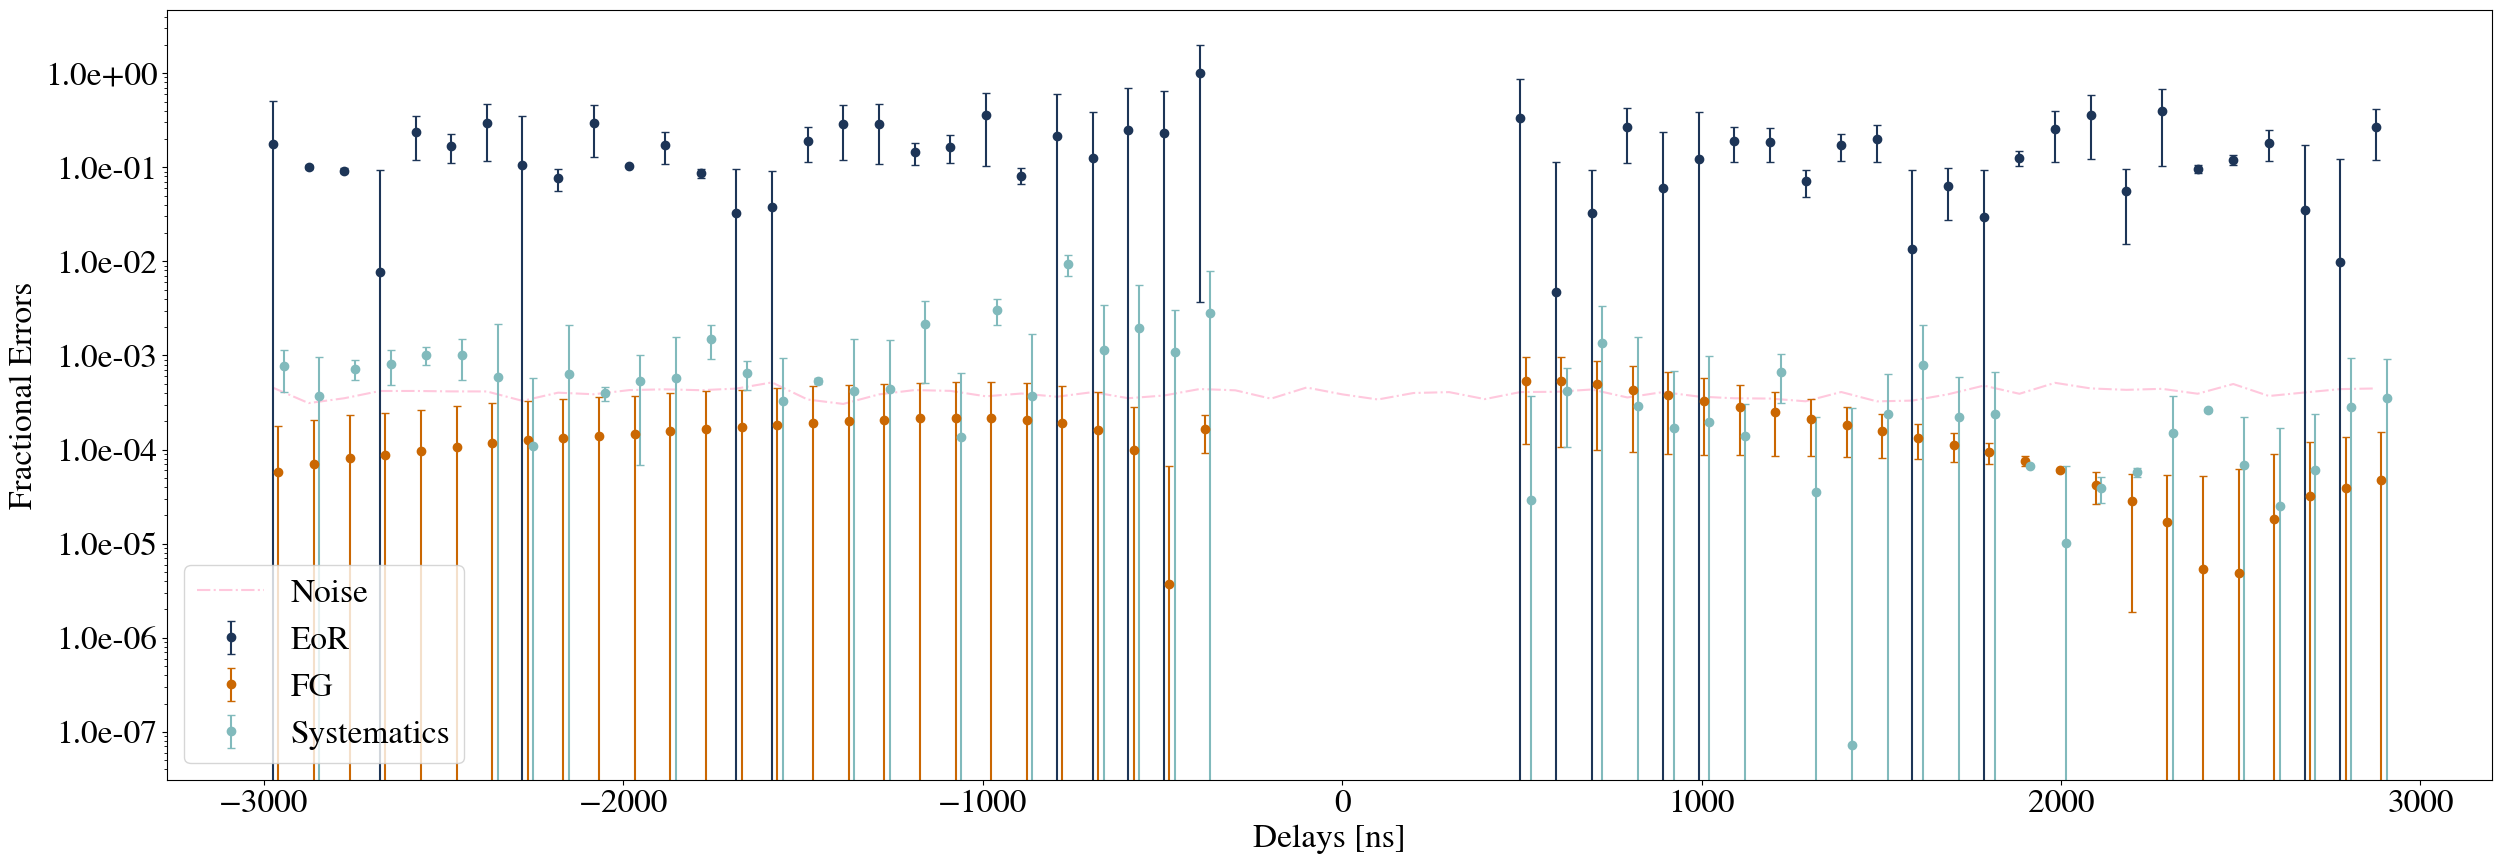

In [38]:
'''Plotting abs errors with log yscale'''
fig, axs = plt.subplots(1,1,figsize=(30,10))

data_arr = [(eor_pspec_true-ps_sample)/eor_pspec_true,(fg_pspec_true-ps_fg)/fg_pspec_true,(sys_pspec_true-ps_sys)/sys_pspec_true]
plot_arr = [data_arr[0].mean(axis=0),data_arr[1].mean(axis=0),data_arr[2].mean(axis=0)]
fig_labels=['EoR','FG','Systematics','Noise']

rm = np.arange(27,35)
keep = np.ones(len(plot_arr[0]),dtype=bool)
keep[rm]=False


axs.plot(delays,np.abs(n_pspec),ls='-.',c=colors[-1],label=fig_labels[-1])

for i in range(3):
    if i<2:
        plot_arr[i]=plot_arr[i][keep]
        data_arr[i]=data_arr[i][:,keep]
        std = np.std(np.abs(data_arr[i]),axis=0)
        errs=np.vstack((
            plot_arr[i] - std,
            std - plot_arr[i]
        ))
        axs.errorbar(
        delays[keep].value+(i*15),
        np.abs(plot_arr[i]),
        yerr=np.abs(errs),   # symmetric errors
        fmt='o',
        color=colors[i],
        label=fig_labels[i],
        capsize=3
        )
        axs.legend()
        mu  = np.abs(data_arr[i].mean(axis=0))          # (4,)
        sig = np.abs(data_arr[i].std(axis=0, ddof=1))   # (4,)  use ddof=1 for sample std
    else:
        plot_arr[i]=plot_arr[i][keep]
        data_arr[i]=data_arr[i][:,keep]
        std = np.std(np.abs(data_arr[i]),axis=0)
        errs=np.vstack((
            plot_arr[i] - std,
            std - plot_arr[i]
        ))
        axs.errorbar(
        delays[keep].value+(i*15),
        np.abs(plot_arr[i]),
        yerr=np.abs(errs),   # symmetric errors
        fmt='o',
        color=colors[i],
        label=fig_labels[i],
        capsize=3
        )
        axs.legend()
        mu  = np.abs(data_arr[i].mean(axis=0))          # (4,)
        sig = np.abs(data_arr[i].std(axis=0, ddof=1))   # (4,)  use ddof=1 for sample std


    # 3-sigma band + mean points
    # plt.fill_between(
    #     delays.value+(i*15), mu - sig, mu + sig,
    #     color=colors[i], alpha=0.20, linewidth=0, label=r"$\pm 3\sigma$"
    # )
    


# plt.ylim(-0.001,0.001)
axs.set_yscale('log')

axs.set_xlabel('Delays [ns]')
axs.set_ylabel('Fractional Errors')
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))

# plt.savefig(fig_dir+'/errors_components.pdf',bbox_inches='tight',dpi=300)

# Figure 8 : Corner plot

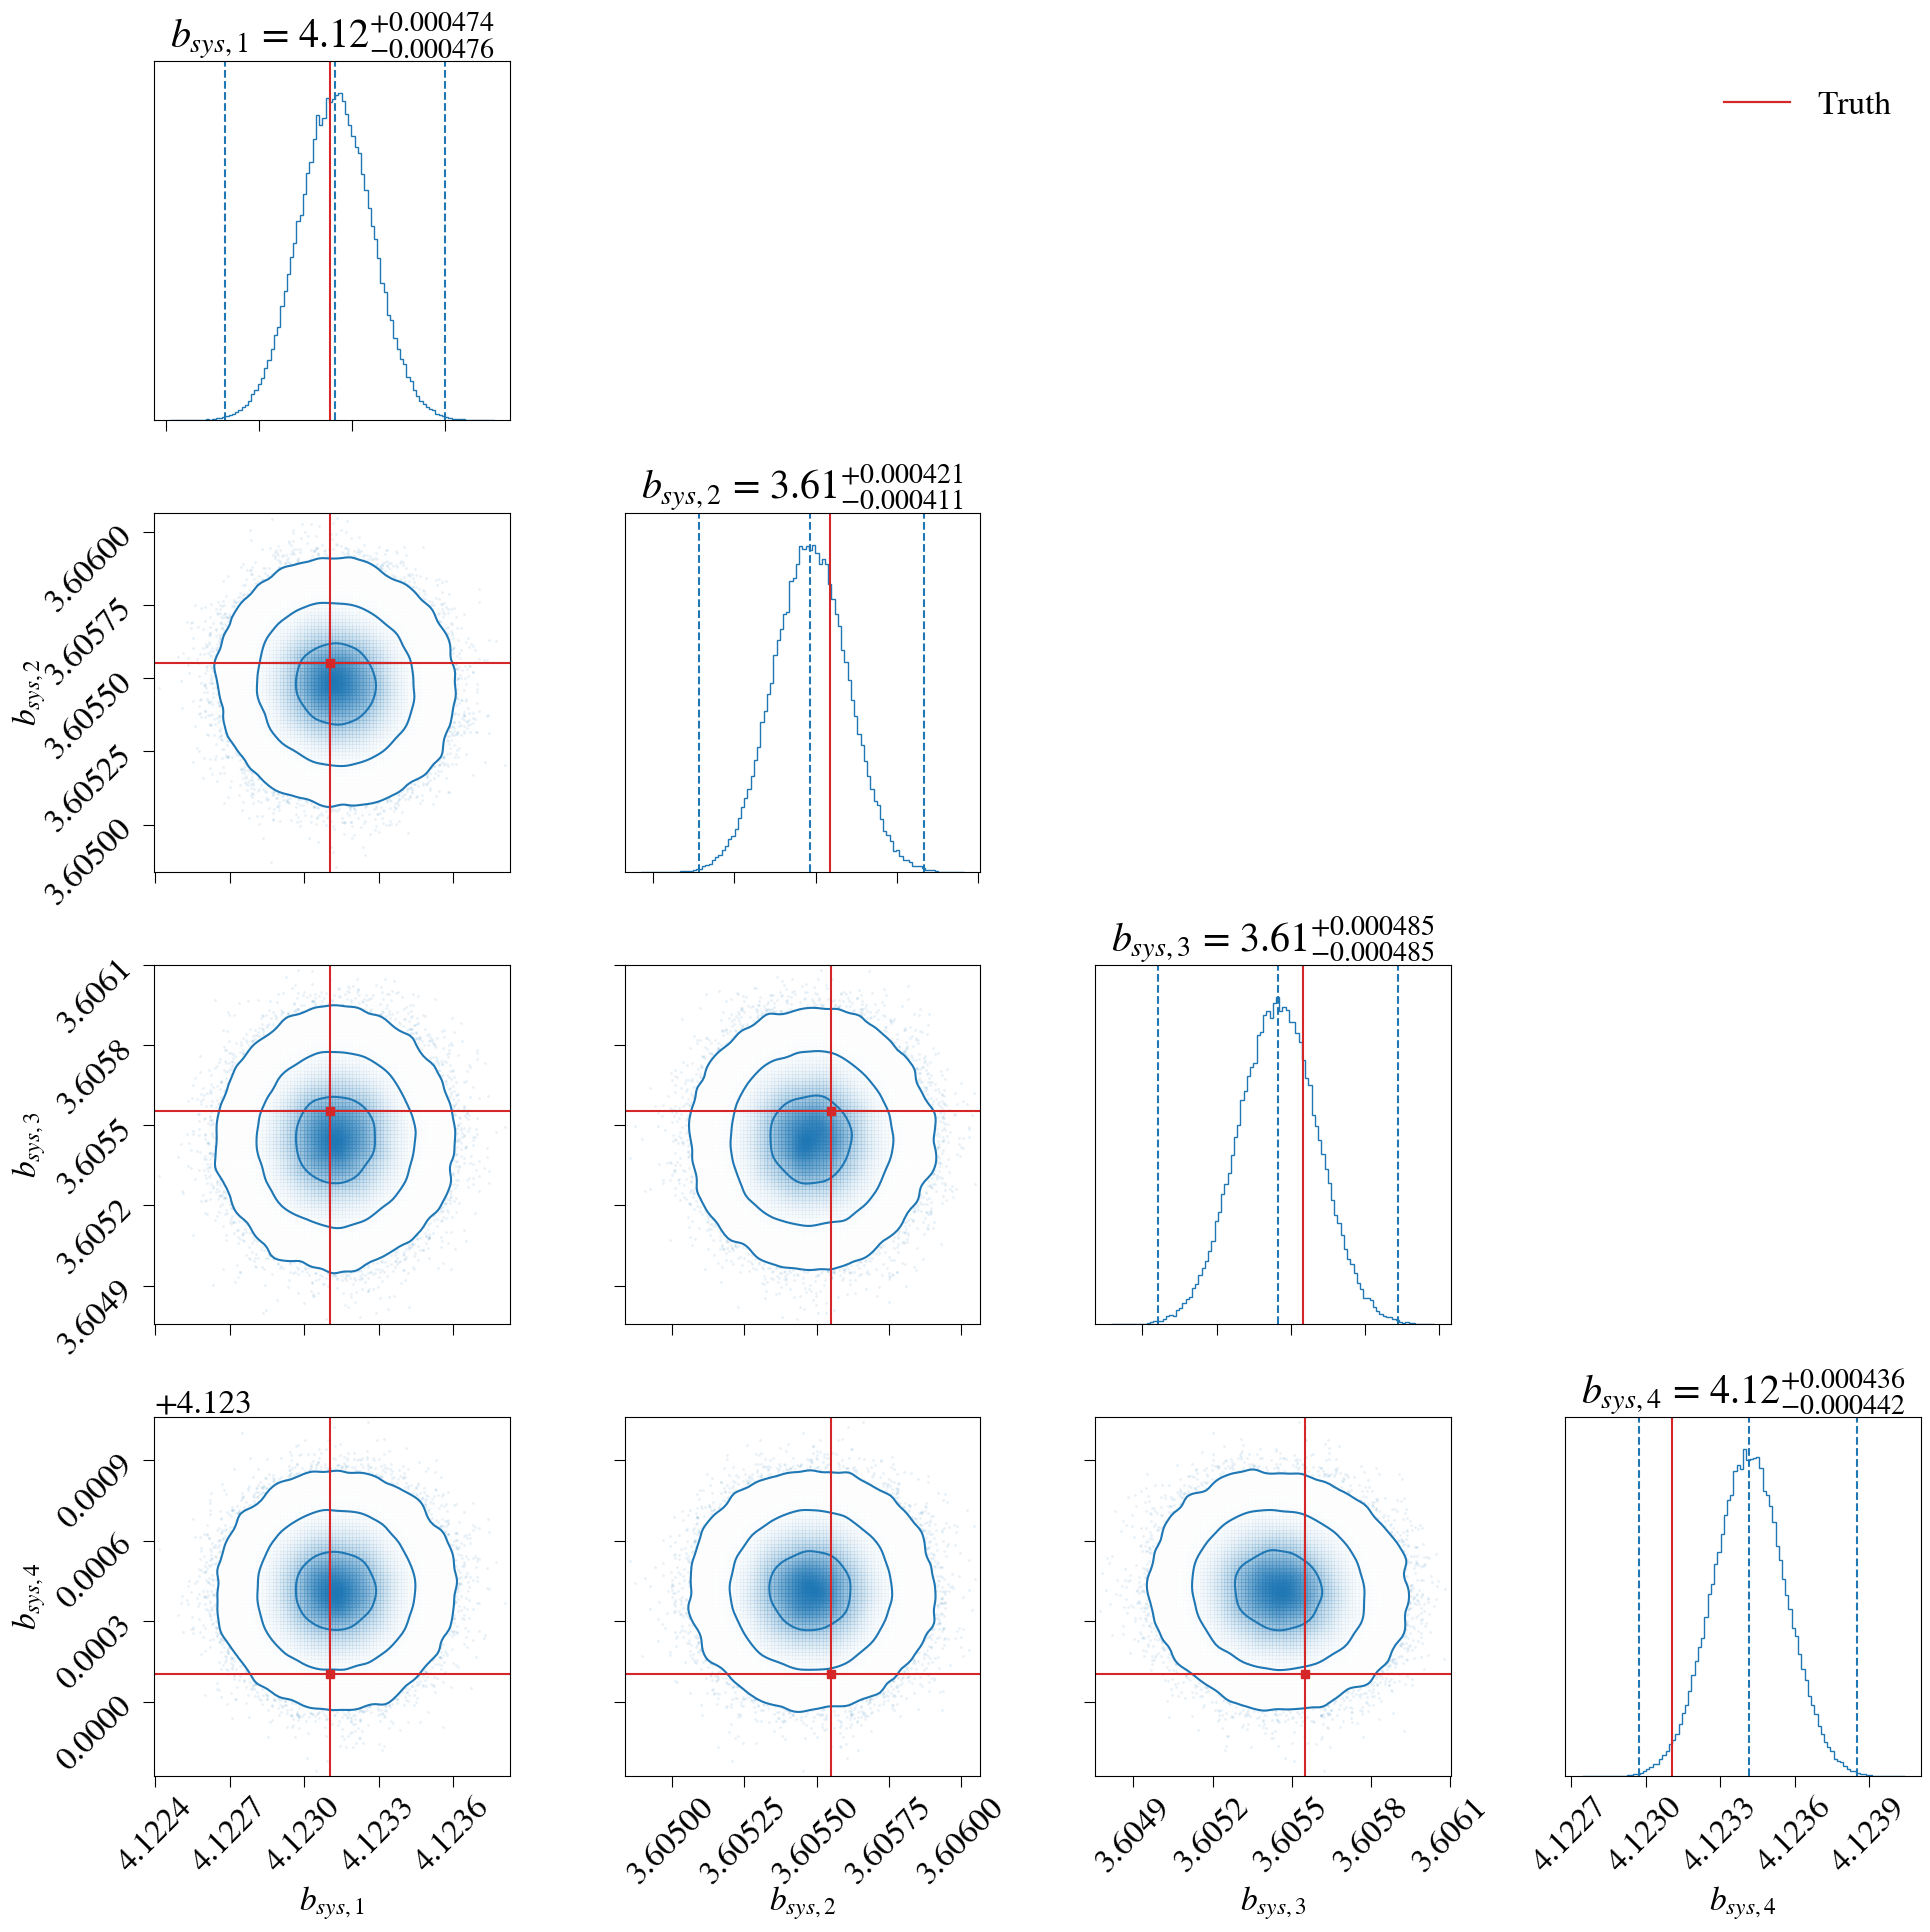

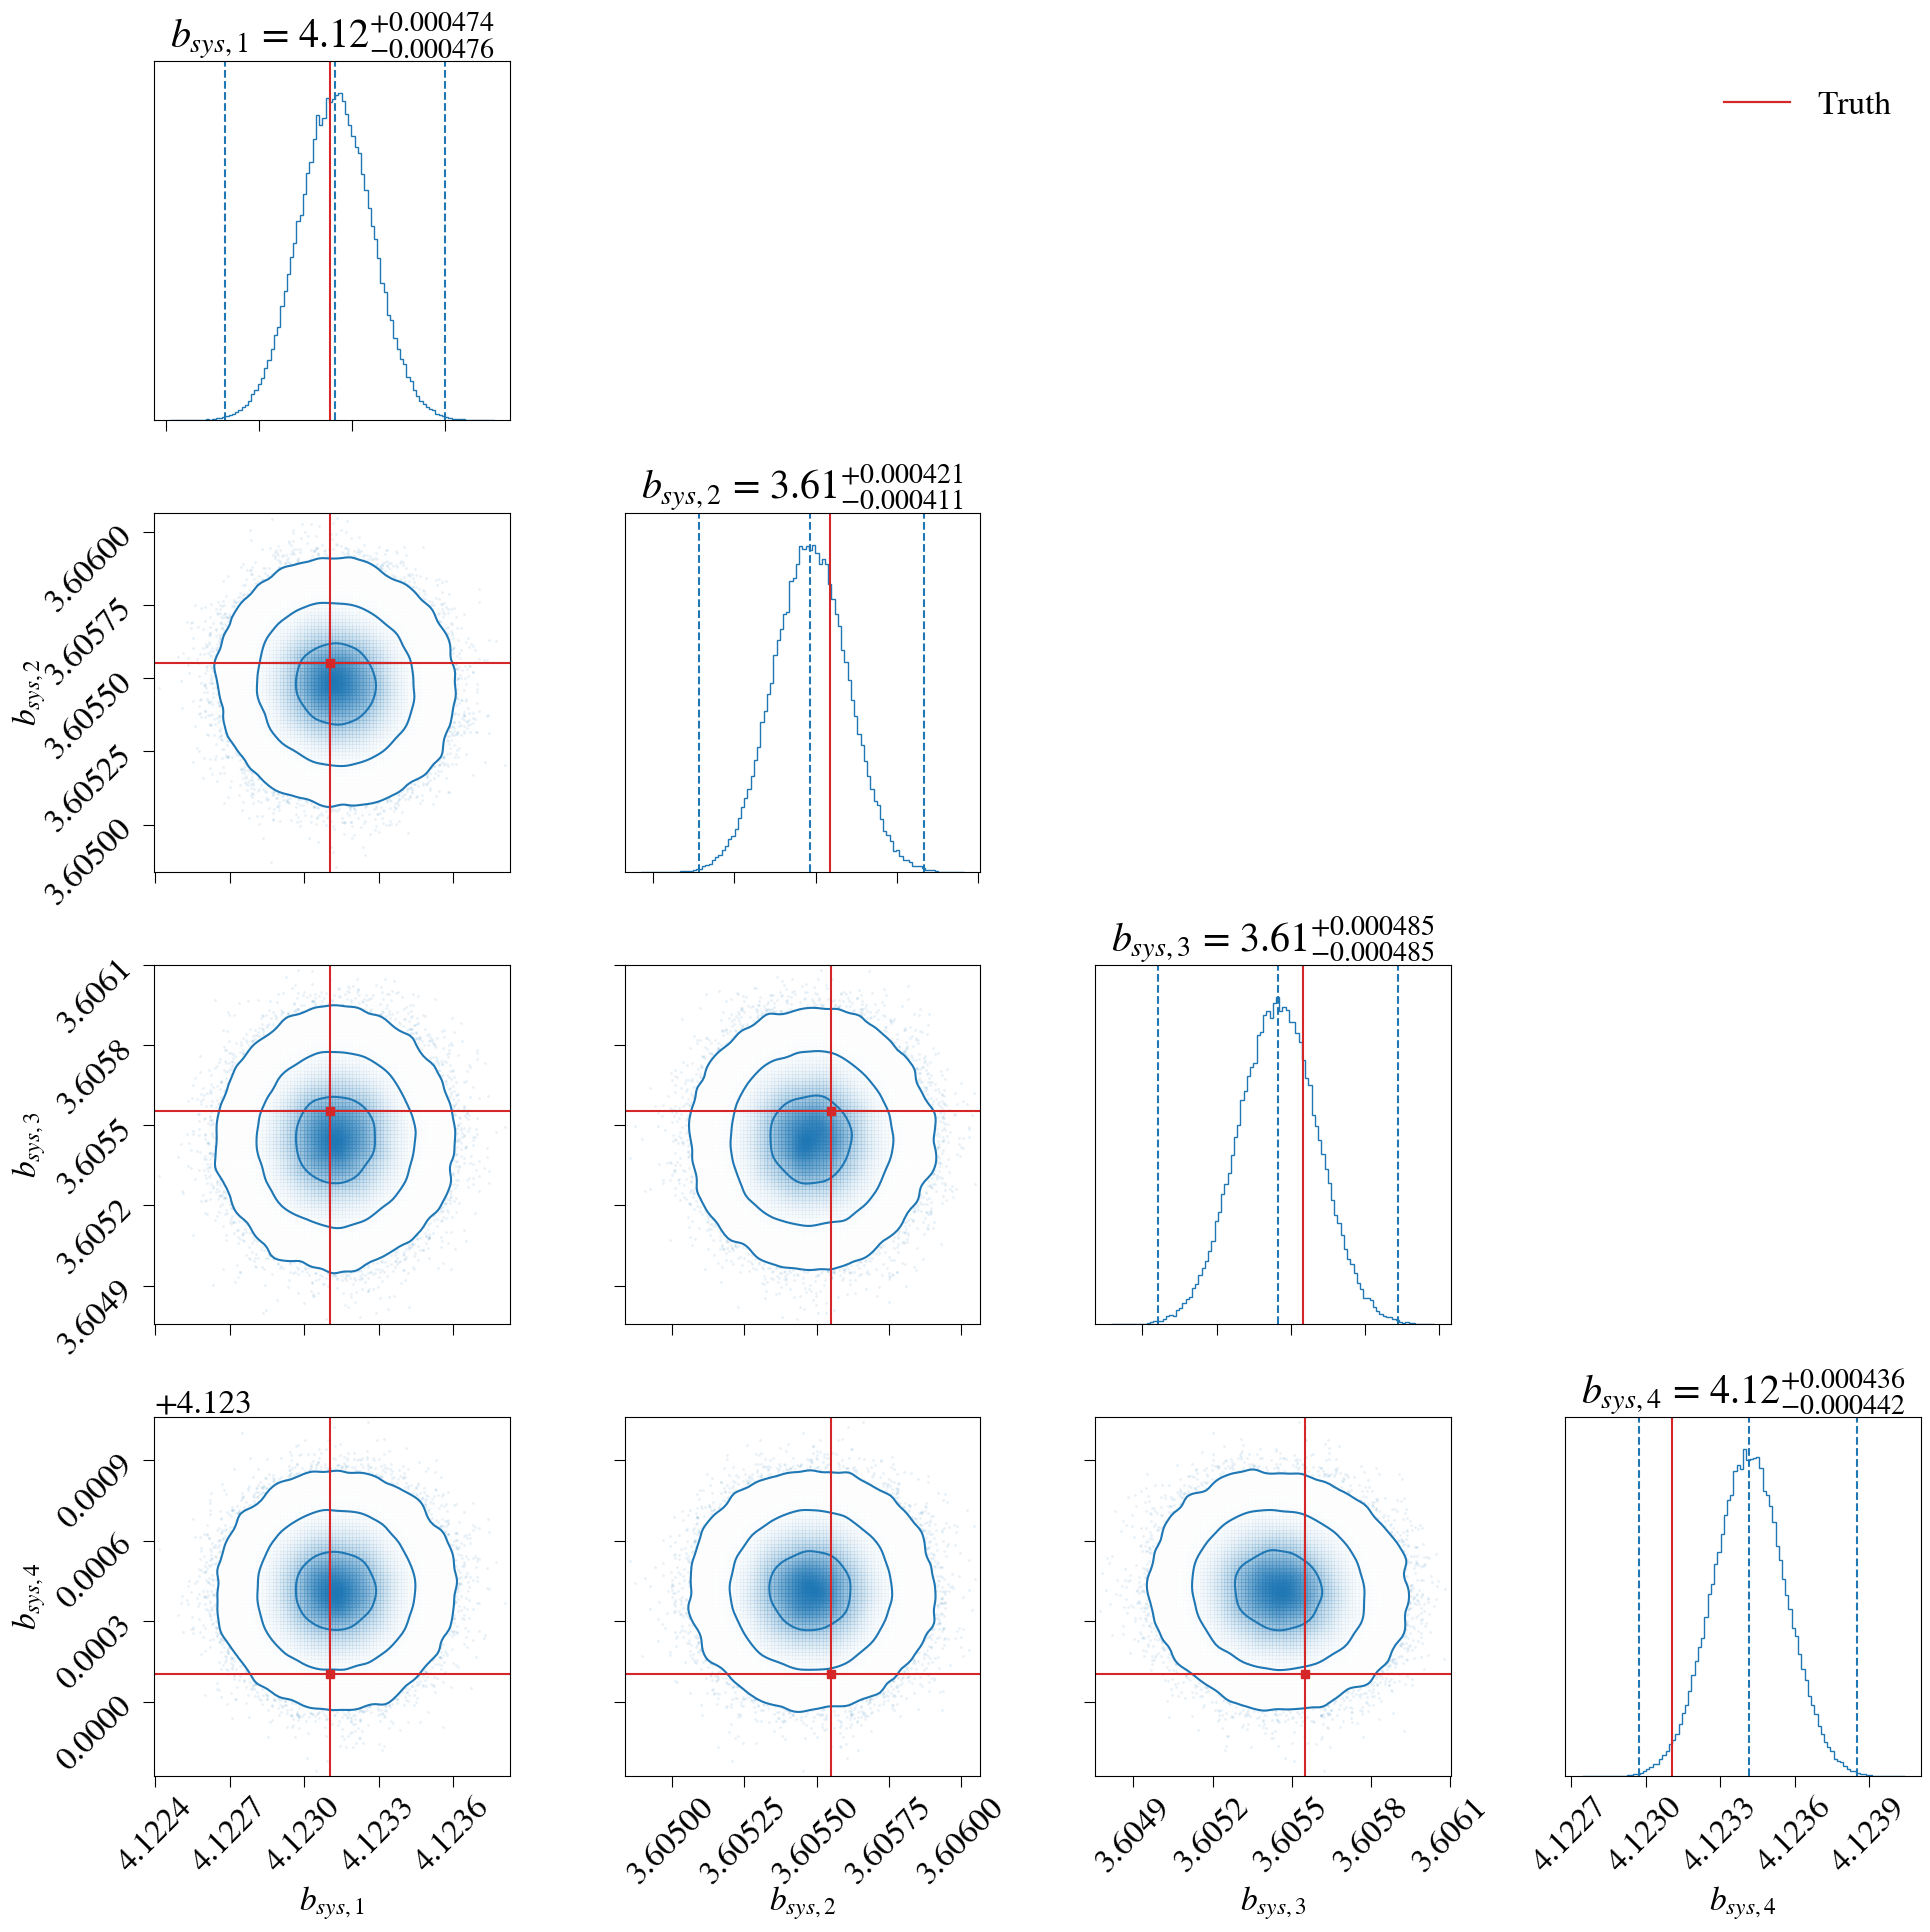

In [31]:
'''B_sys corner plots'''
def corner_plot(
    samples, labels=None, truths=None, burn=0, thin=1, fig=None,
    truths_label="Truth",
    extra_truths=None, extra_color="tab:green", extra_truths_label="Truth B",
    title=None, legend_loc="best",
    nsigma=3,
):
    S = samples[burn::thin]
    ndim = S.shape[1]

    # 2D contour levels corresponding to 1/2/3-sigma in 2D
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]

    # 1D central interval for nsigma (Gaussian assumption)
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        # generic: use error function inverse if you want; keeping explicit is safer
        raise ValueError("nsigma must be 1, 2, or 3 for this helper.")

    fig = corner.corner(
        S, labels=labels, truths=truths,
        truth_color="tab:red",
        quantiles=quantiles,
        levels=levels,
        fig=fig,
        show_titles=True, title_fmt=".3g",
        bins=100, smooth=2.0, color="C0",
    )

    # Optional second set of truths
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)

    # Legend (put it on the first diagonal axis)
    axes = np.array(fig.axes).reshape(ndim, ndim)
    ax0 = axes[0, -1]

    legend_handles = []
    if truths is not None:
        legend_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        legend_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))

    if legend_handles:
        ax0.legend(handles=legend_handles, loc=legend_loc, frameon=False)

    # Overall title (optional)
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()

    return fig


# usage
# samples shape: (n, 4)
fig,ax = plt.subplots(4,4,figsize=(20,20))

for a in ax.flatten():
    a.tick_params(length=8)
corner_plot(np.abs(b_sys_gcr),
            truths=np.abs(sys_amps_true),
            labels=[r"$b_{sys,1}$", r"$b_{sys,2}$", r"$b_{sys,3}$", r"$b_{sys,4}$"],
            fig=fig,
            nsigma=3)
# plt.savefig(fig_dir+'/bsys_corner_plot.pdf',bbox_inches='tight',dpi=300)

#NOTE: These are 3 sigma bounds. Change by updating the nsigma parameter in the corner_plot function.

# Figure 9: Systematics fractional error

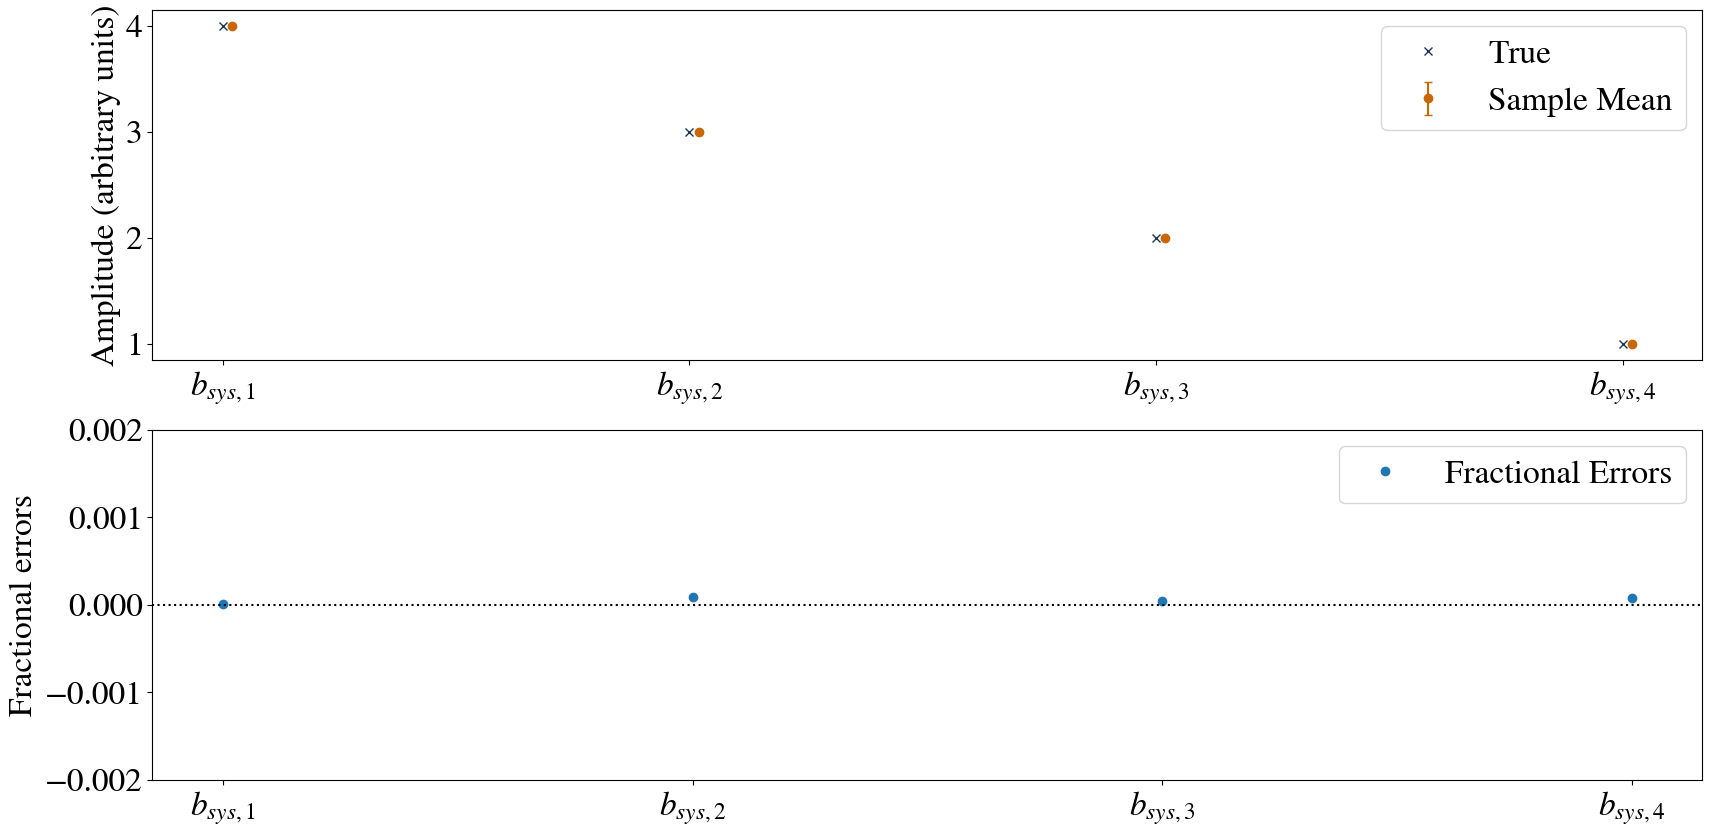

In [32]:
fig,ax=plt.subplots(2,1,figsize=(20,10))

errs=np.vstack((
        np.imag(3*np.std(b_sys_gcr,axis=0)),
        np.imag(3*np.std(b_sys_gcr,axis=0))
        # np.std(b_sys_gcr,axis=0) - b_sys_gcr.mean(axis=0)
    ))

ax[0].plot(np.imag(sys_amps_true),'x',c=colors[0],label='True')
ax[0].errorbar([0.02,1.02,2.02,3.02],
    np.imag(b_sys_gcr.mean(axis=0)),
    fmt='o',
    yerr=errs,
    label='Sample Mean',
    capsize=3,
    c=colors[1])
ax[0].set_ylabel("Amplitude (arbitrary units)")
ax[0].set_xticks([0,1,2,3],labels=[r"$b_{sys,1}$", r"$b_{sys,2}$", r"$b_{sys,3}$", r"$b_{sys,4}$"])

res_mean=np.abs(sys_amps_true-b_sys_gcr.mean(axis=0))/np.abs(sys_amps_true)
res=np.abs(sys_amps_true-b_sys_gcr)/np.abs(sys_amps_true)

ax[0].legend()

ax[1].plot([0,1,2,3],
               res_mean,
               'o',
               label='Fractional Errors')
ax[1].set_xticks([0,1,2,3],labels=[r"$b_{sys,1}$", r"$b_{sys,2}$", r"$b_{sys,3}$", r"$b_{sys,4}$"])
ax[1].axhline(0,c='k',ls='dotted')
ax[1].set_ylabel("Fractional errors")
ax[1].set_ylim(-0.002,0.002)
ax[1].legend()
# plt.savefig(fig_dir+'/sys_frac_error.pdf',bbox_inches='tight',dpi=300)

# Figure 10: The delay power spectra

0.3573392044548749
0.36320190495430005
0.22928705023342058
0.33145072250454344


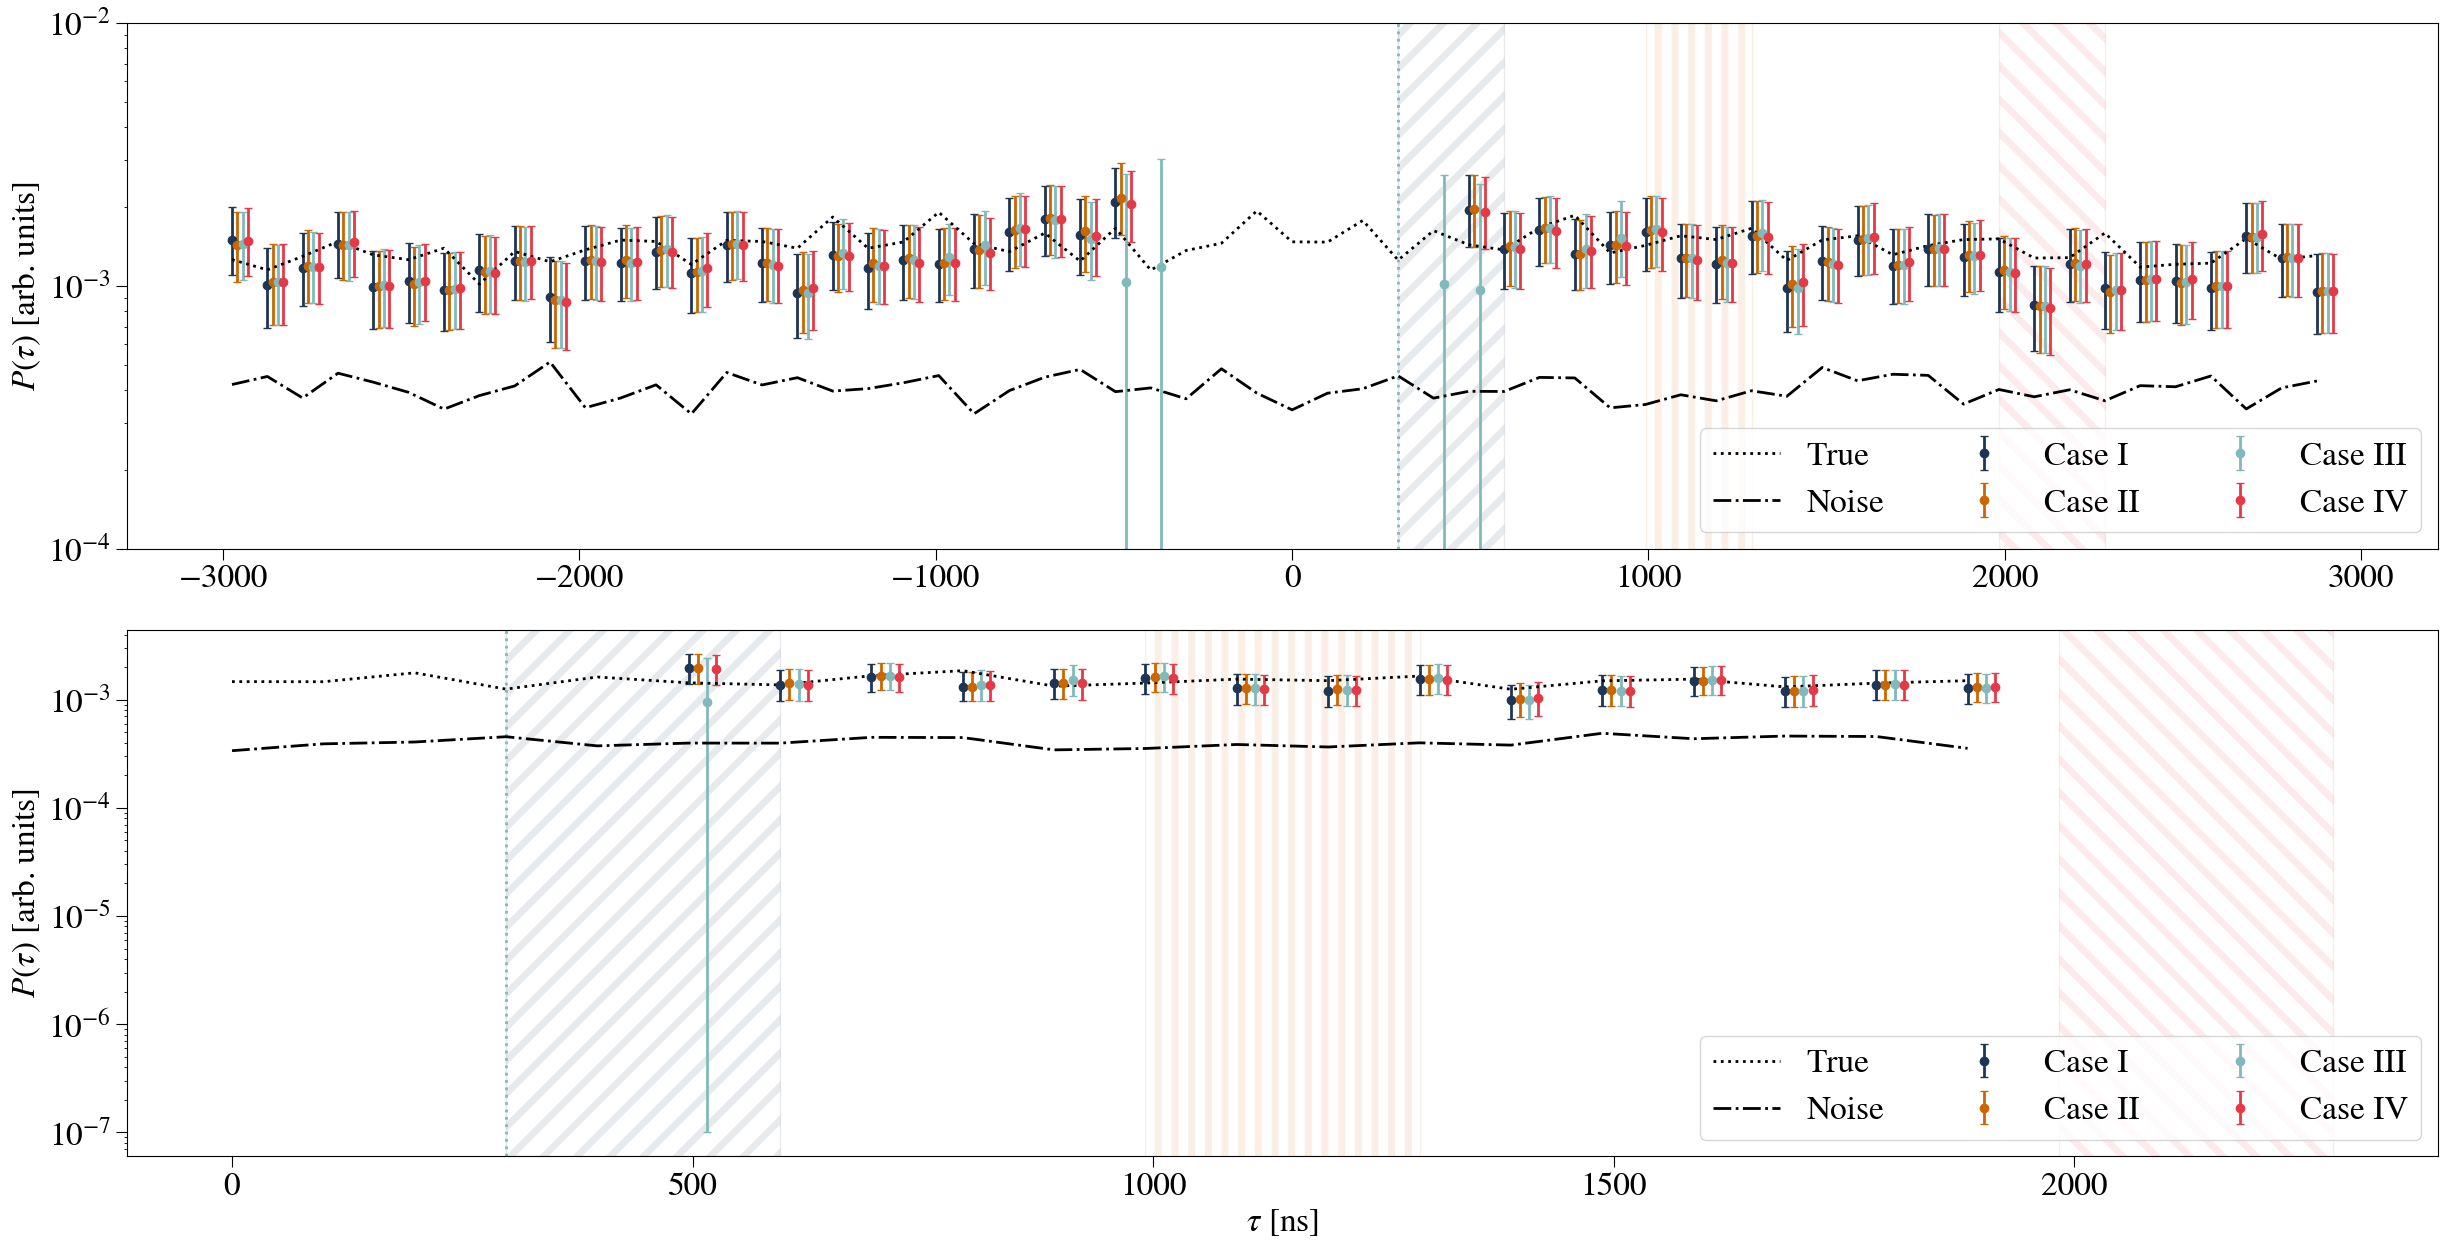

In [40]:
'''Plotting fig_11 and fig 10 together'''

# run_version_arr = ['masked_data','high_dl_fr_0','low_dl_low_fr']
result_dir='/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/100k_runs/'

bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)

fig, ax = plt.subplots(2,1,figsize=(25, 13))

i=0
fig_labels=['I','II','III','IV','Residuals']
rm = np.arange(27,35)
keep = np.ones(60,dtype=bool)
keep[rm]=False

hatches=['/','|','.','\\']
for run_version in run_version_arr:
    eor_true=np.load(result_dir+run_version+'/eor_true.npy')
    ps_sample = np.load(result_dir+run_version+'/dps-eor.npy')
    ln_post = np.load(result_dir+run_version+'/ln-post.npy')
    ps_true = calc_ps(eor_true[:Ntimes,:Nfreqs])
    ps_mean = np.mean(ps_sample, axis=0)

    sys_delays= delays[np.unique(dl_inds[i])+int(Nfreqs/2)].value
    if Nburn > 0:
        ps_sample = ps_sample[Nburn:]
        ln_post = ln_post[Nburn:]
    # Posterior-weighted mean delay power spectrum
    dps_eor_hp_pwm = np.average(ps_sample, weights=ln_post, axis=0)
    
    # Confidence interval of delay power spectrum posteriors
    percentile = conf_interval/2 + 50
    dps_eor_hp_ubound = np.percentile(ps_sample, percentile, axis=0)
    dps_eor_hp_lbound = np.percentile(ps_sample, 100-percentile, axis=0)
    dps_eor_hp_err = np.vstack((
        dps_eor_hp_pwm - dps_eor_hp_lbound,
        dps_eor_hp_ubound - dps_eor_hp_pwm
    ))
    
    ax[0].errorbar(
                    delays.value+i*15,
                    dps_eor_hp_pwm,
                    yerr=np.abs(dps_eor_hp_err),
                    color=colors[i],
                    ls="",
                    marker="o",
                    elinewidth=2,
                    capsize=3,
                    label=f"Case "+fig_labels[i]
                    )
    
    x0, x1 = np.min(sys_delays), np.max(sys_delays)   # the x-range to shade
    ax[0].axvspan(x0, x1, facecolor='none',ec=colors[i],hatch=hatches[i], hatch_linewidth=5,alpha=0.1, zorder=0.1)
    ax[-1].axvspan(x0, x1, facecolor='none',ec=colors[i],hatch=hatches[i], hatch_linewidth=5,alpha=0.1, zorder=0.1)

    if i==2:
        for dl in sys_delays:
            ax[0].axvline(dl,ls='dotted',c=colors[i],lw=2)
            ax[-1].axvline(dl,ls='dotted',c=colors[i],lw=2)

    ax[-1].errorbar(
                        delays[35:50].value+i*10,
                        dps_eor_hp_pwm[35:50],
                        yerr=np.abs(dps_eor_hp_err[:,35:50]),
                        color=colors[i],
                        ls="",
                        marker="o",
                        elinewidth=2,
                        capsize=3,
                        label=f"Case "+fig_labels[i]
                        )
    # ax[-1].grid()
    print(max((dps_eor_hp_pwm-ps_true)/ps_true))
    i=i+1

ax[-1].set_ylabel(r"$P(\tau)$ [arb. units]")
ax[-1].set_xlabel(r'$\tau$ [ns]')
ax[-1].axhline(0,ls='dotted')
ax[-1].plot(delays[30:50], ps_true[30:50], "k:", label="True",lw=2)
ax[-1].plot(delays[30:50],calc_ps(n.T)[30:50],'k',ls='-.',label='Noise',lw=2)
ax[-1].legend(loc="lower right",ncol=3)

ax[-1].set_yscale('log')
ax[0].plot(delays, ps_true, "k:", label="True",lw=2)
ax[0].plot(delays,calc_ps(n.T),'k',ls='-.',label='Noise',lw=2)
ax[0].legend(loc="lower right",ncol=3)
ax[0].set_ylabel(r"$P(\tau)$ [arb. units]")
ax[0].set_ylim(1e-4,1e-2)
# ax.set_title("EoR Delay Power Spectrum Comparison")
ax[0].set_yscale("log")
# ax[i].grid()

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()

# plt.savefig(fig_dir+'/delay_power_spectrum_combined.pdf',bbox_inches='tight',dpi=300)

## Average fractional residuals:

Mean:  -0.10886583705473675 <br>
Mean:  -0.10357718021502864 <br>
Mean:  -0.1075680463532779 <br>

## Old figure

Mean:  -0.10953886062016342
Mean:  -0.10331126120721268
Mean:  -0.10993212394160559
Mean:  -0.10842230781932538


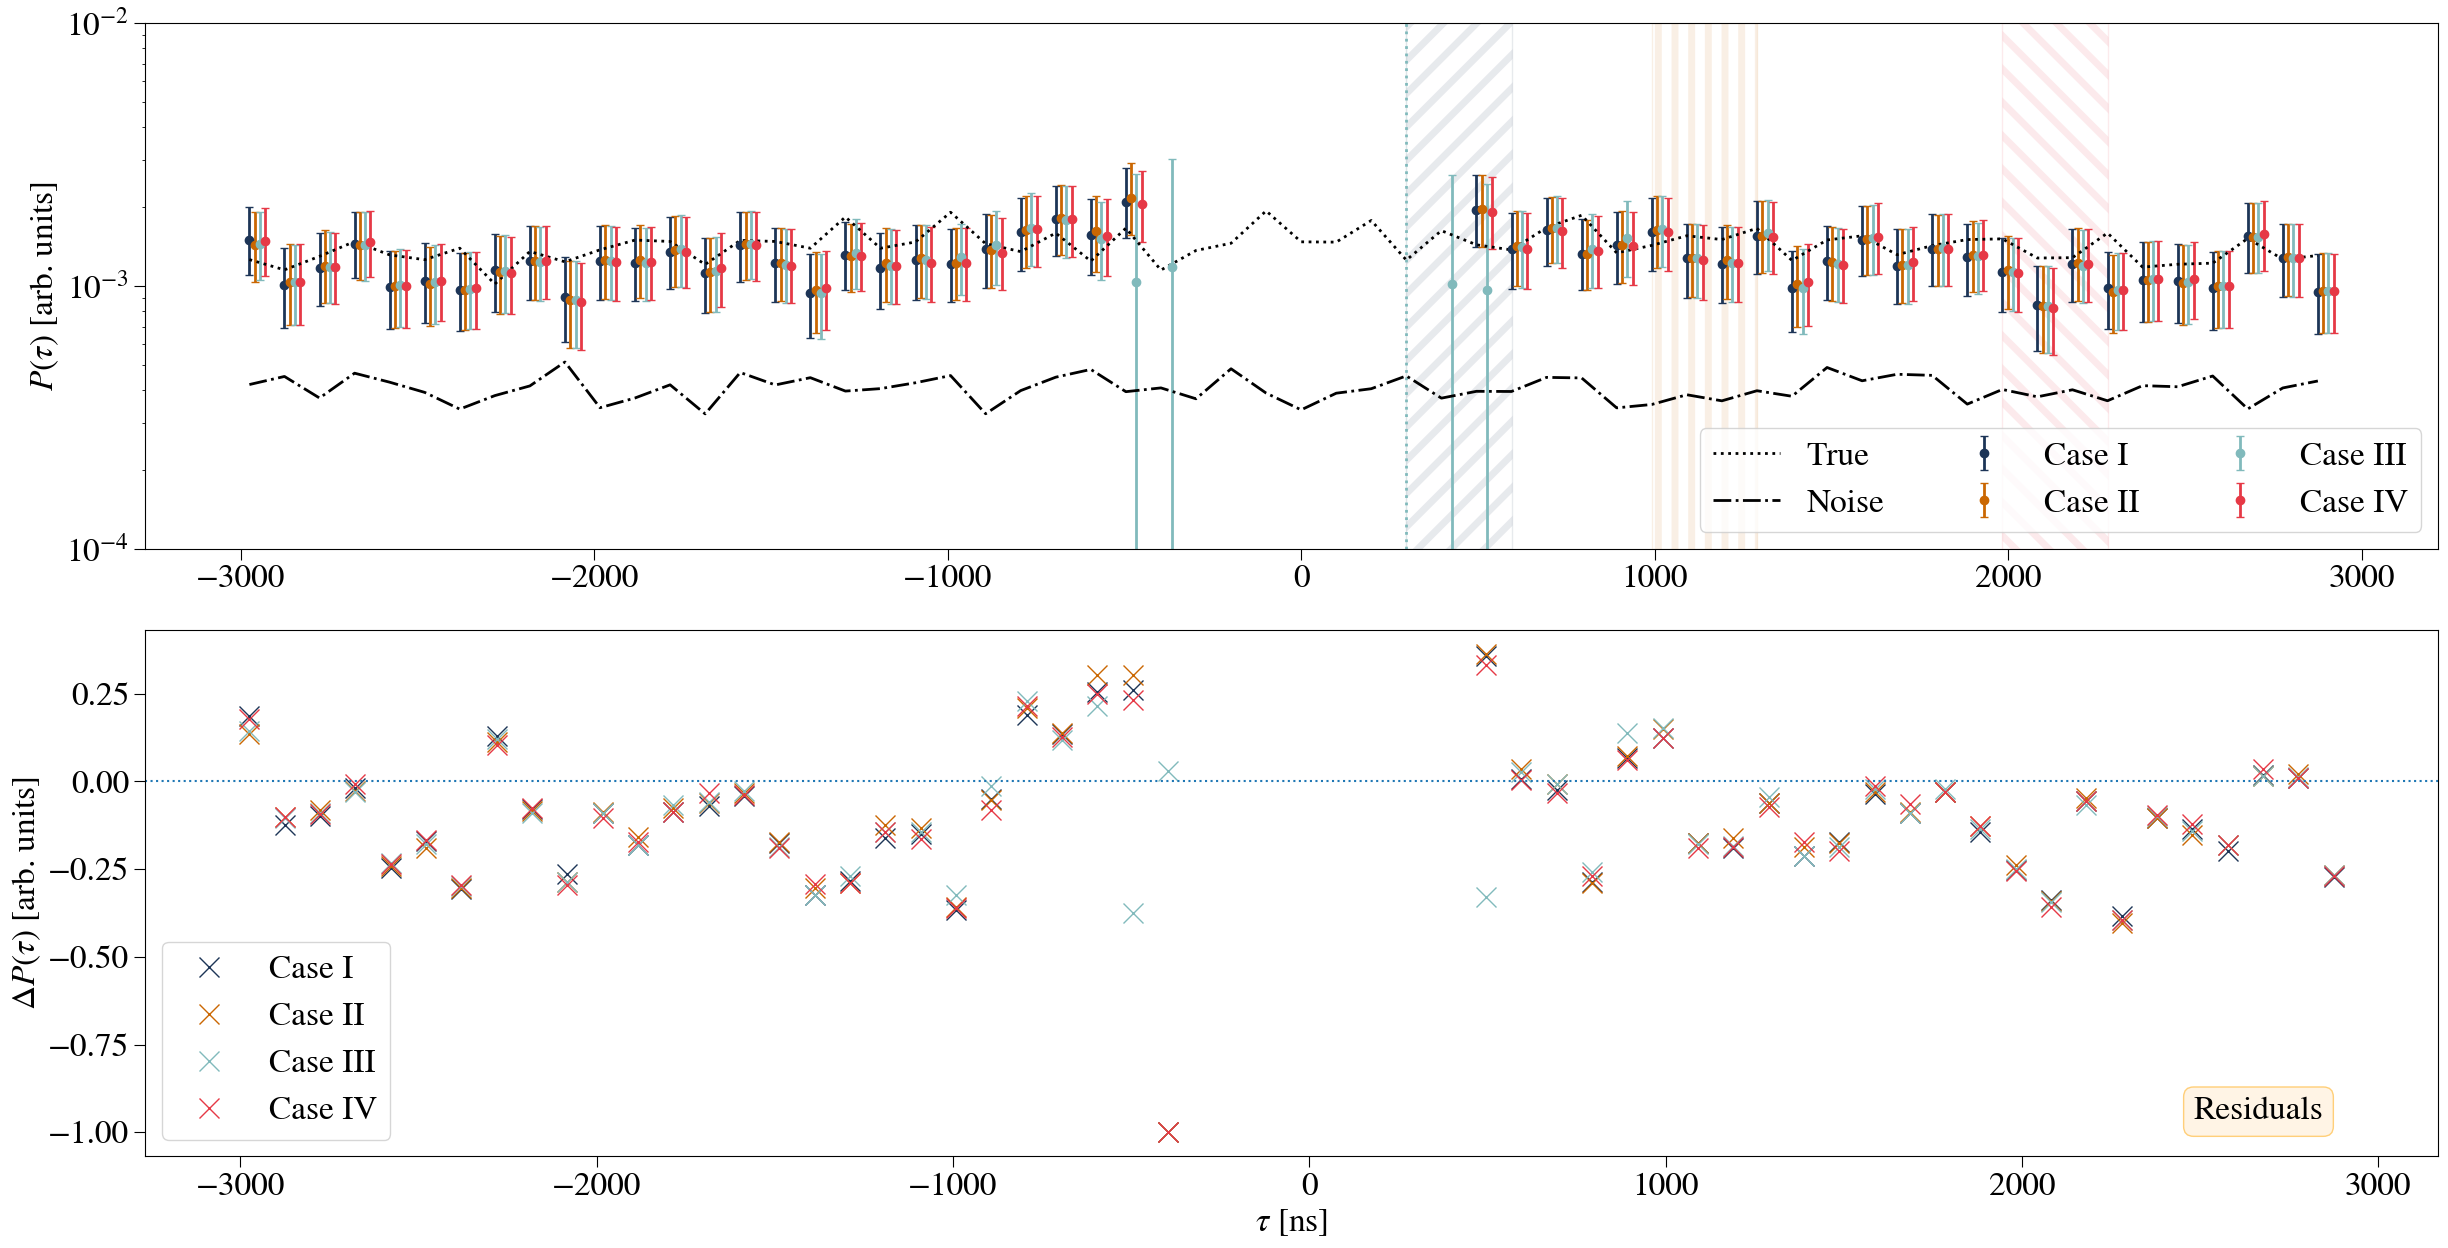

In [41]:
# run_version_arr = ['masked_data','high_dl_fr_0','low_dl_low_fr']
result_dir='/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/100k_runs/'

bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)

fig, ax = plt.subplots(2,1,figsize=(25, 13))

i=0
fig_labels=['I','II','III','IV','Residuals']
rm = np.arange(27,35)
keep = np.ones(60,dtype=bool)
keep[rm]=False

hatches=['/','|','.','\\']
for run_version in run_version_arr:
    eor_true=np.load(result_dir+run_version+'/eor_true.npy')
    ps_sample = np.load(result_dir+run_version+'/dps-eor.npy')
    ln_post = np.load(result_dir+run_version+'/ln-post.npy')
    ps_true = calc_ps(eor_true[:Ntimes,:Nfreqs])
    ps_mean = np.mean(ps_sample, axis=0)

    sys_delays= delays[np.unique(dl_inds[i])+int(Nfreqs/2)].value
    if Nburn > 0:
        ps_sample = ps_sample[Nburn:]
        ln_post = ln_post[Nburn:]
    # Posterior-weighted mean delay power spectrum
    dps_eor_hp_pwm = np.average(ps_sample, weights=ln_post, axis=0)
    
    # Confidence interval of delay power spectrum posteriors
    percentile = conf_interval/2 + 50
    dps_eor_hp_ubound = np.percentile(ps_sample, percentile, axis=0)
    dps_eor_hp_lbound = np.percentile(ps_sample, 100-percentile, axis=0)
    dps_eor_hp_err = np.vstack((
        dps_eor_hp_pwm - dps_eor_hp_lbound,
        dps_eor_hp_ubound - dps_eor_hp_pwm
    ))
    
    ax[0].errorbar(
                    delays.value+i*15,
                    dps_eor_hp_pwm,
                    yerr=np.abs(dps_eor_hp_err),
                    color=colors[i],
                    ls="",
                    marker="o",
                    elinewidth=2,
                    capsize=3,
                    label=f"Case "+fig_labels[i]
                    )
    
    x0, x1 = np.min(sys_delays), np.max(sys_delays)   # the x-range to shade
    ax[0].axvspan(x0, x1, facecolor='none',ec=colors[i],hatch=hatches[i], hatch_linewidth=5,alpha=0.1, zorder=0.1)
    # ax[-1].axvspan(x0, x1, color=colors[i], alpha=0.1, ec=None, zorder=0.1)

    if i==2:
        for dl in sys_delays:
            ax[0].axvline(dl,ls='dotted',c=colors[i],lw=2)

    ax[-1].plot(delays[keep],(dps_eor_hp_pwm[keep]-ps_true[keep])/ps_true[keep],'x',color=colors[i],label=f"Case "+fig_labels[i],ms=15)
    ax[-1].set_ylabel(r"$\Delta P(\tau)$ [arb. units]")
    ax[-1].set_xlabel(r'$\tau$ [ns]')
    ax[-1].legend()
    # ax[-1].grid()
    print("Mean: ",((dps_eor_hp_pwm[keep]-ps_true[keep])/ps_true[keep]).mean(axis=0))
    i=i+1
ax[-1].text(0.95,0.07,fig_labels[-1], bbox=bbox,
            transform=ax[-1].transAxes, horizontalalignment='right')
ax[-1].axhline(0,ls='dotted')

ax[0].plot(delays, ps_true, "k:", label="True",lw=2)
ax[0].plot(delays,calc_ps(n.T),'k',ls='-.',label='Noise',lw=2)
ax[0].legend(loc="lower right",ncol=3)
ax[0].set_ylabel(r"$P(\tau)$ [arb. units]")
ax[0].set_ylim(1e-4,1e-2)
# ax.set_title("EoR Delay Power Spectrum Comparison")
ax[0].set_yscale("log")
# ax[i].grid()

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()

# plt.savefig(fig_dir+'/delay_power_spectrum_full.pdf',bbox_inches='tight',dpi=300)

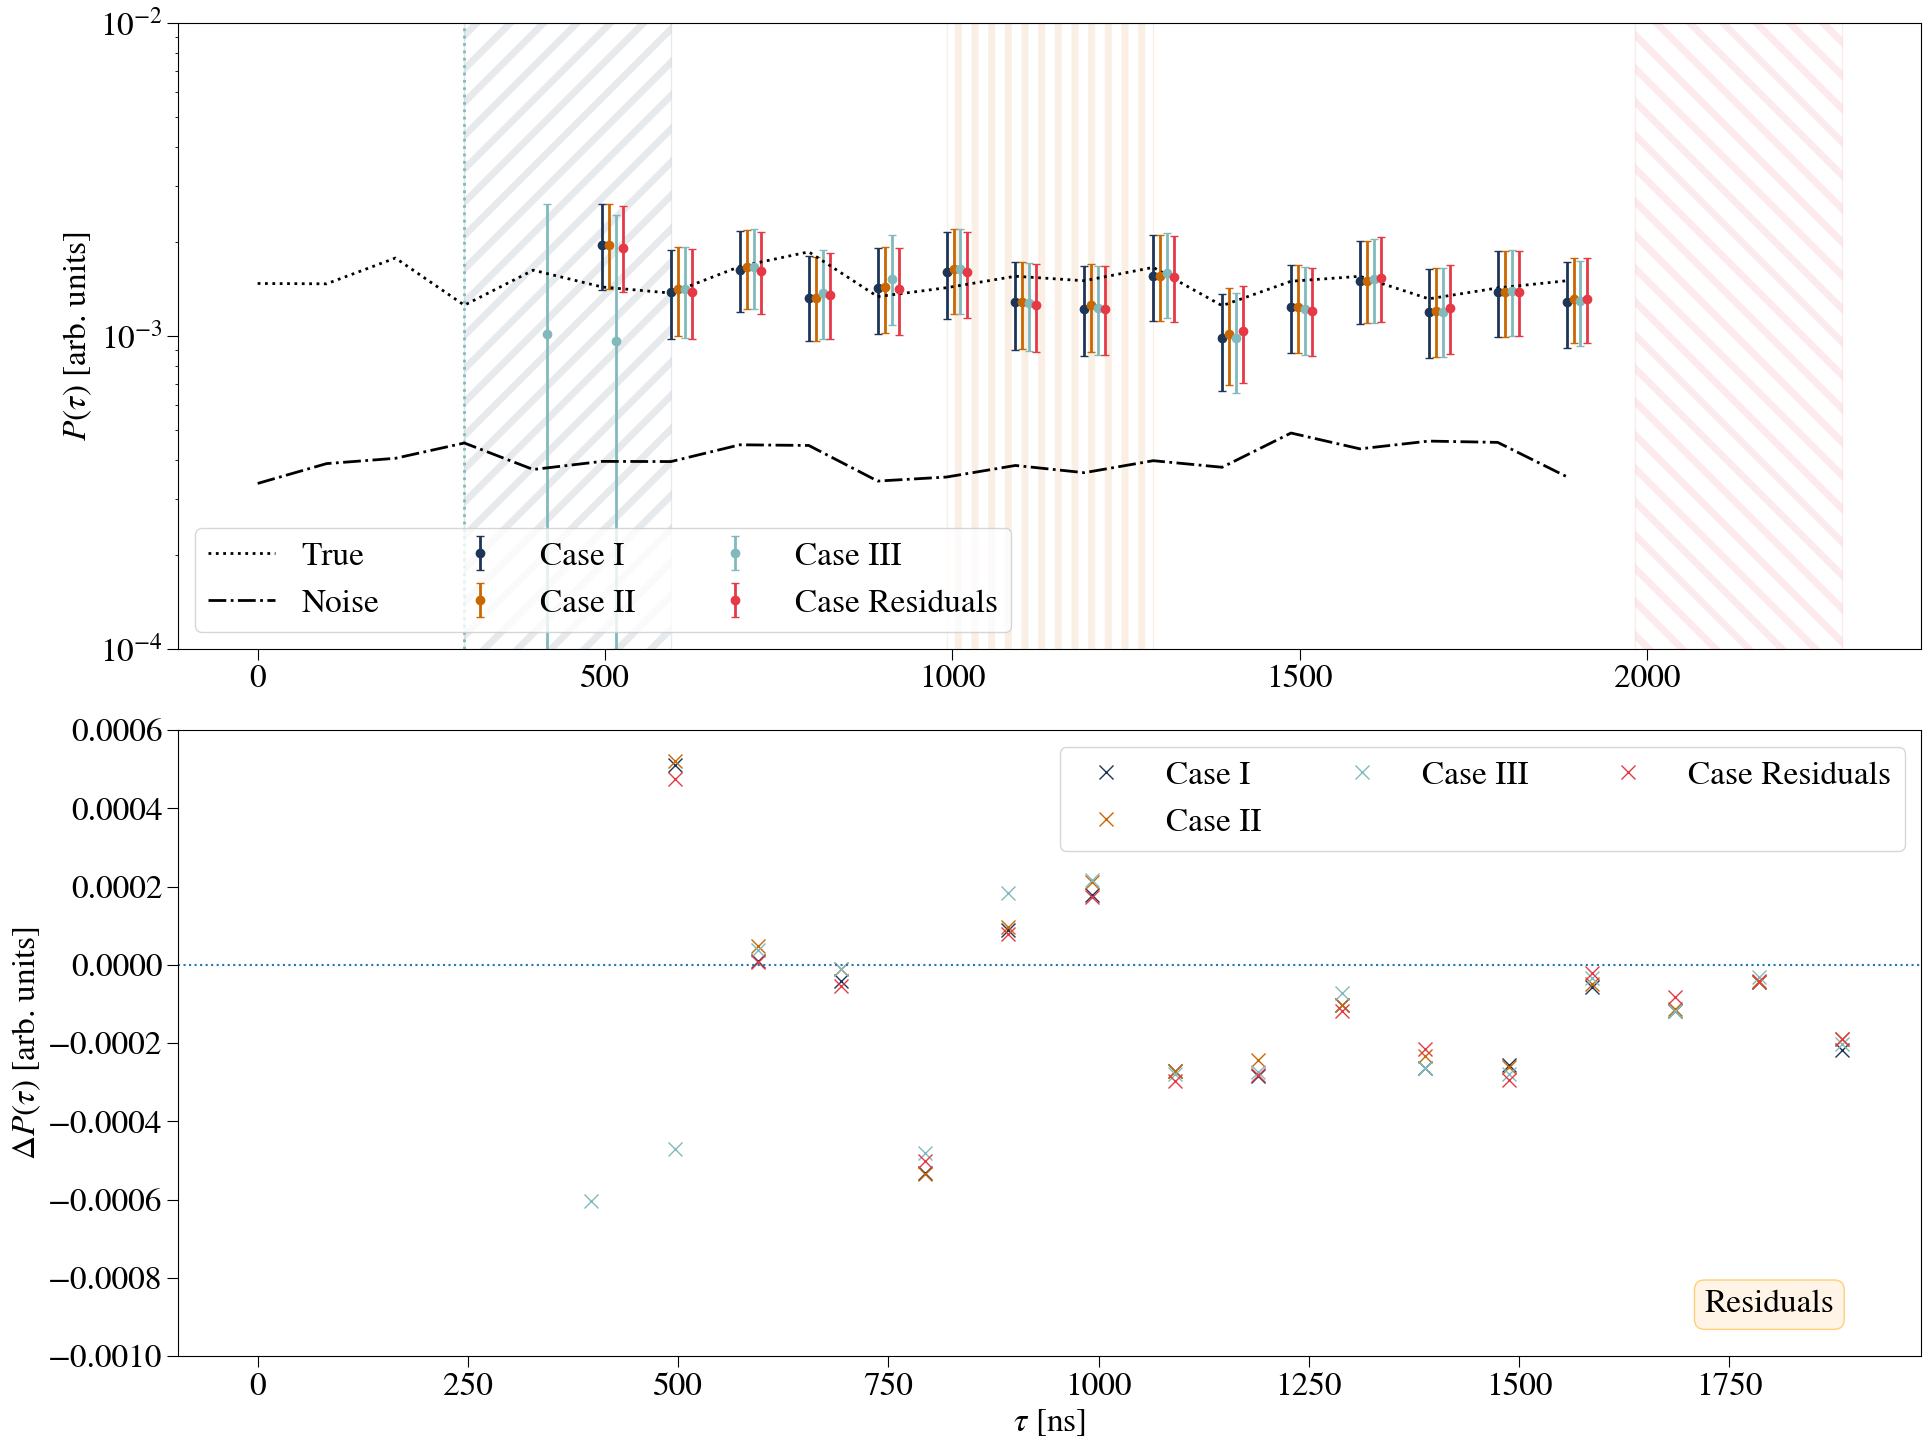

In [42]:

bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)

fig, ax = plt.subplots(2,1,figsize=(20, 15))
i=0
fig_labels=['I','II','III','Residuals']
for run_version in run_version_arr:
    eor_true=np.load(result_dir+'high_dl_fr_0/eor_true.npy')
    ps_sample = np.load(result_dir+run_version+'/dps-eor.npy')
    ln_post = np.load(result_dir+run_version+'/ln-post.npy')
    ps_true = calc_ps(eor_true[:Ntimes,:Nfreqs])
    ps_mean = np.mean(ps_sample, axis=0)
    df = (freqs[1] - freqs[0]) * u.MHz
    delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to("1/ns")))

 
    sys_delays= delays[np.unique(dl_inds[i])+int(Nfreqs/2)].value
    if Nburn > 0:
        ps_sample = ps_sample[Nburn:]
        ln_post = ln_post[Nburn:]
    # Posterior-weighted mean delay power spectrum
    dps_eor_hp_pwm = np.average(ps_sample, weights=ln_post, axis=0)
    
    # Confidence interval of delay power spectrum posteriors
    percentile = conf_interval/2 + 50
    dps_eor_hp_ubound = np.percentile(ps_sample, percentile, axis=0)
    dps_eor_hp_lbound = np.percentile(ps_sample, 100-percentile, axis=0)
    dps_eor_hp_err = np.vstack((
        dps_eor_hp_pwm - dps_eor_hp_lbound,
        dps_eor_hp_ubound - dps_eor_hp_pwm
    ))
    
    ax[0].errorbar(
                    delays[30:50].value+i*10,
                    dps_eor_hp_pwm[30:50],
                    yerr=np.abs(dps_eor_hp_err[:,30:50]),
                    color=colors[i],
                    ls="",
                    marker="o",
                    elinewidth=2,
                    capsize=3,
                    label=f"Case "+fig_labels[i]
                    )
    
    x0, x1 = np.min(sys_delays), np.max(sys_delays)   # the x-range to shade
    ax[0].axvspan(x0, x1, facecolor='none',ec=colors[i],hatch=hatches[i], hatch_linewidth=5,alpha=0.1, zorder=0.1)
    # ax[-1].axvspan(x0, x1, color=colors[i], alpha=0.1, ec=None, zorder=0.1)

    if i==2:
        for dl in sys_delays:
            ax[0].axvline(dl,ls='dotted',c=colors[i],lw=2)

    ax[-1].plot(delays[30:50],(dps_eor_hp_pwm-ps_true)[30:50],'x',color=colors[i],label=f"Case "+fig_labels[i],lw=2,ms=10)
    ax[-1].set_ylabel(r"$\Delta P(\tau)$ [arb. units]")
    ax[-1].set_xlabel(r'$\tau$ [ns]')
    ax[-1].legend(ncol=3)
    # ax[-1].grid()

    i=i+1
ax[-1].text(0.95,0.07,fig_labels[-1], bbox=bbox,
            transform=ax[-1].transAxes, horizontalalignment='right')
ax[-1].axhline(0,ls='dotted')
ax[-1].set_ylim(-0.001,0.0006)
ax[0].plot(delays[30:50], ps_true[30:50], "k:", label="True",lw=2)
ax[0].plot(delays[30:50],calc_ps(n.T)[30:50],'k',ls='-.',label='Noise',lw=2)
ax[0].legend(loc="lower left",ncol=3)
ax[0].set_ylabel(r"$P(\tau)$ [arb. units]")
ax[0].set_ylim(1e-4,1e-2)
# ax.set_title("EoR Delay Power Spectrum Comparison")
ax[0].set_yscale("log")
# ax[i].grid()

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()

# plt.savefig(fig_dir+'/delay_power_spectrum.pdf',bbox_inches='tight',dpi=300)


---
# Table 1: sampling efficiency of the systematic amplitudes

How much independent information about $b_\mathrm{sys}$ each case actually
bought, per Gibbs iteration.

* $\tau$ (integrated autocorrelation time) — how many iterations the sampler
  needs before it forgets its previous sample. **Lower is better.**
* $N_\mathrm{eff} = N/\tau$ (effective sample size) — how many *independent*
  draws the chain is worth. **Higher is better.** The table colours it green
  above 1000, amber between 400 and 1000, red below 400 (Vehtari et al. 2021:
  posterior means and 95 % intervals need $N_\mathrm{eff} \gtrsim 400$).

Each row is one complex amplitude, so its $\tau$ combines the real and
imaginary parts.  The fold-out under the table has the same table as Markdown
and LaTeX, ready to paste; `.md`, `.tex`, `.csv` and `.html` copies are written
to `fig_dir/tables`.


In [ ]:
# ── Table 1: sampling efficiency of the systematic amplitudes ───────────────
# Integrated autocorrelation time and effective sample size of each complex
# systematic amplitude, one row per case, with an explicit colour code so the
# table can be pasted into an email or the paper as it stands.
result_dir = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/100k_runs/'

b_sys_chains = {
    run_version: np.load(result_dir + run_version + '/b-sys.npy')[:Niter]
    for run_version in run_version_arr
}

table1 = tbl.ess_table(
    b_sys_chains,
    title='Table 1 — sampling efficiency of the systematic amplitudes b_sys',
    subtitle=('Integrated autocorrelation time and effective sample size of each '
              'complex systematic amplitude, from the full chain of every case.'),
    name='table1_ess_bsys',
)

del b_sys_chains


---
### Figure T1: $\tau$ and ESS per systematic mode → `ess_tau_bsys.pdf`

Table 1 drawn, so the comparison between cases can be seen at a glance.  Left:
$\tau$ per amplitude (log scale, lower is better).  Right: ESS, with the
quality bands shaded — red below 400 (unreliable), amber 400 to 1000 (usable),
green above 1000 (comfortable).


In [ ]:
fig = tbl.plot_ess_tau(table1, figsize=(30, 11))
plt.savefig(fig_dir + '/ess_tau_bsys.pdf', bbox_inches='tight', dpi=300)

# Markdown / LaTeX / CSV / HTML copies of the table, ready to send on.
tbl.save_tables(fig_dir + '/tables')


# Figure 11: Correlation plots: FG and Bsys

In [44]:
def plot_crosscor_pearson(data1,data2):
    # reshape to (Nsamples, Npix)
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)

    # subtract means
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)

    # compute correlation per pixel
    numerator = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))

    corr = numerator / denominator

    # reshape back to image
    corr_map = corr.reshape(data1.shape[1:])
    
    return corr_map

In [45]:
xticklocs=[1,10,20,30,40,50,59]
yticklocs=[1,10,20,30,40,50,60,70]

lsts_round=np.array([round(l,2) for l in lsts])
times = Quantity(np.unique(lsts_round * 12 / np.pi), unit='h')
fringe_rates = fourier_freqs(lsts * u.day.to('s')) * 1e3 # mHz

xstep_dl = (delays[-1]-delays[0])/delays.size
ystep_fr = (fringe_rates[-1]-fringe_rates[0])/Ntimes

xticks_dl= delays[xticklocs]
yticks_fr=fringe_rates[yticklocs]

xticklabels_dl = [str(int(round(val,2))) for val in xticks_dl.value]
yticklabels_fr = [f"{val:.2f}" for val in yticks_fr]

Foregrounds...


100%|██████████| 100000/100000 [00:16<00:00, 5935.40it/s]


Systematics...


100%|██████████| 100000/100000 [00:52<00:00, 1919.00it/s]


Foregrounds...


...

100%|██████████| 100000/100000 [00:59<00:00, 1677.00it/s]


Foregrounds...


100%|██████████| 100000/100000 [00:17<00:00, 5852.32it/s]


Systematics...


100%|██████████| 100000/100000 [01:11<00:00, 1393.38it/s]


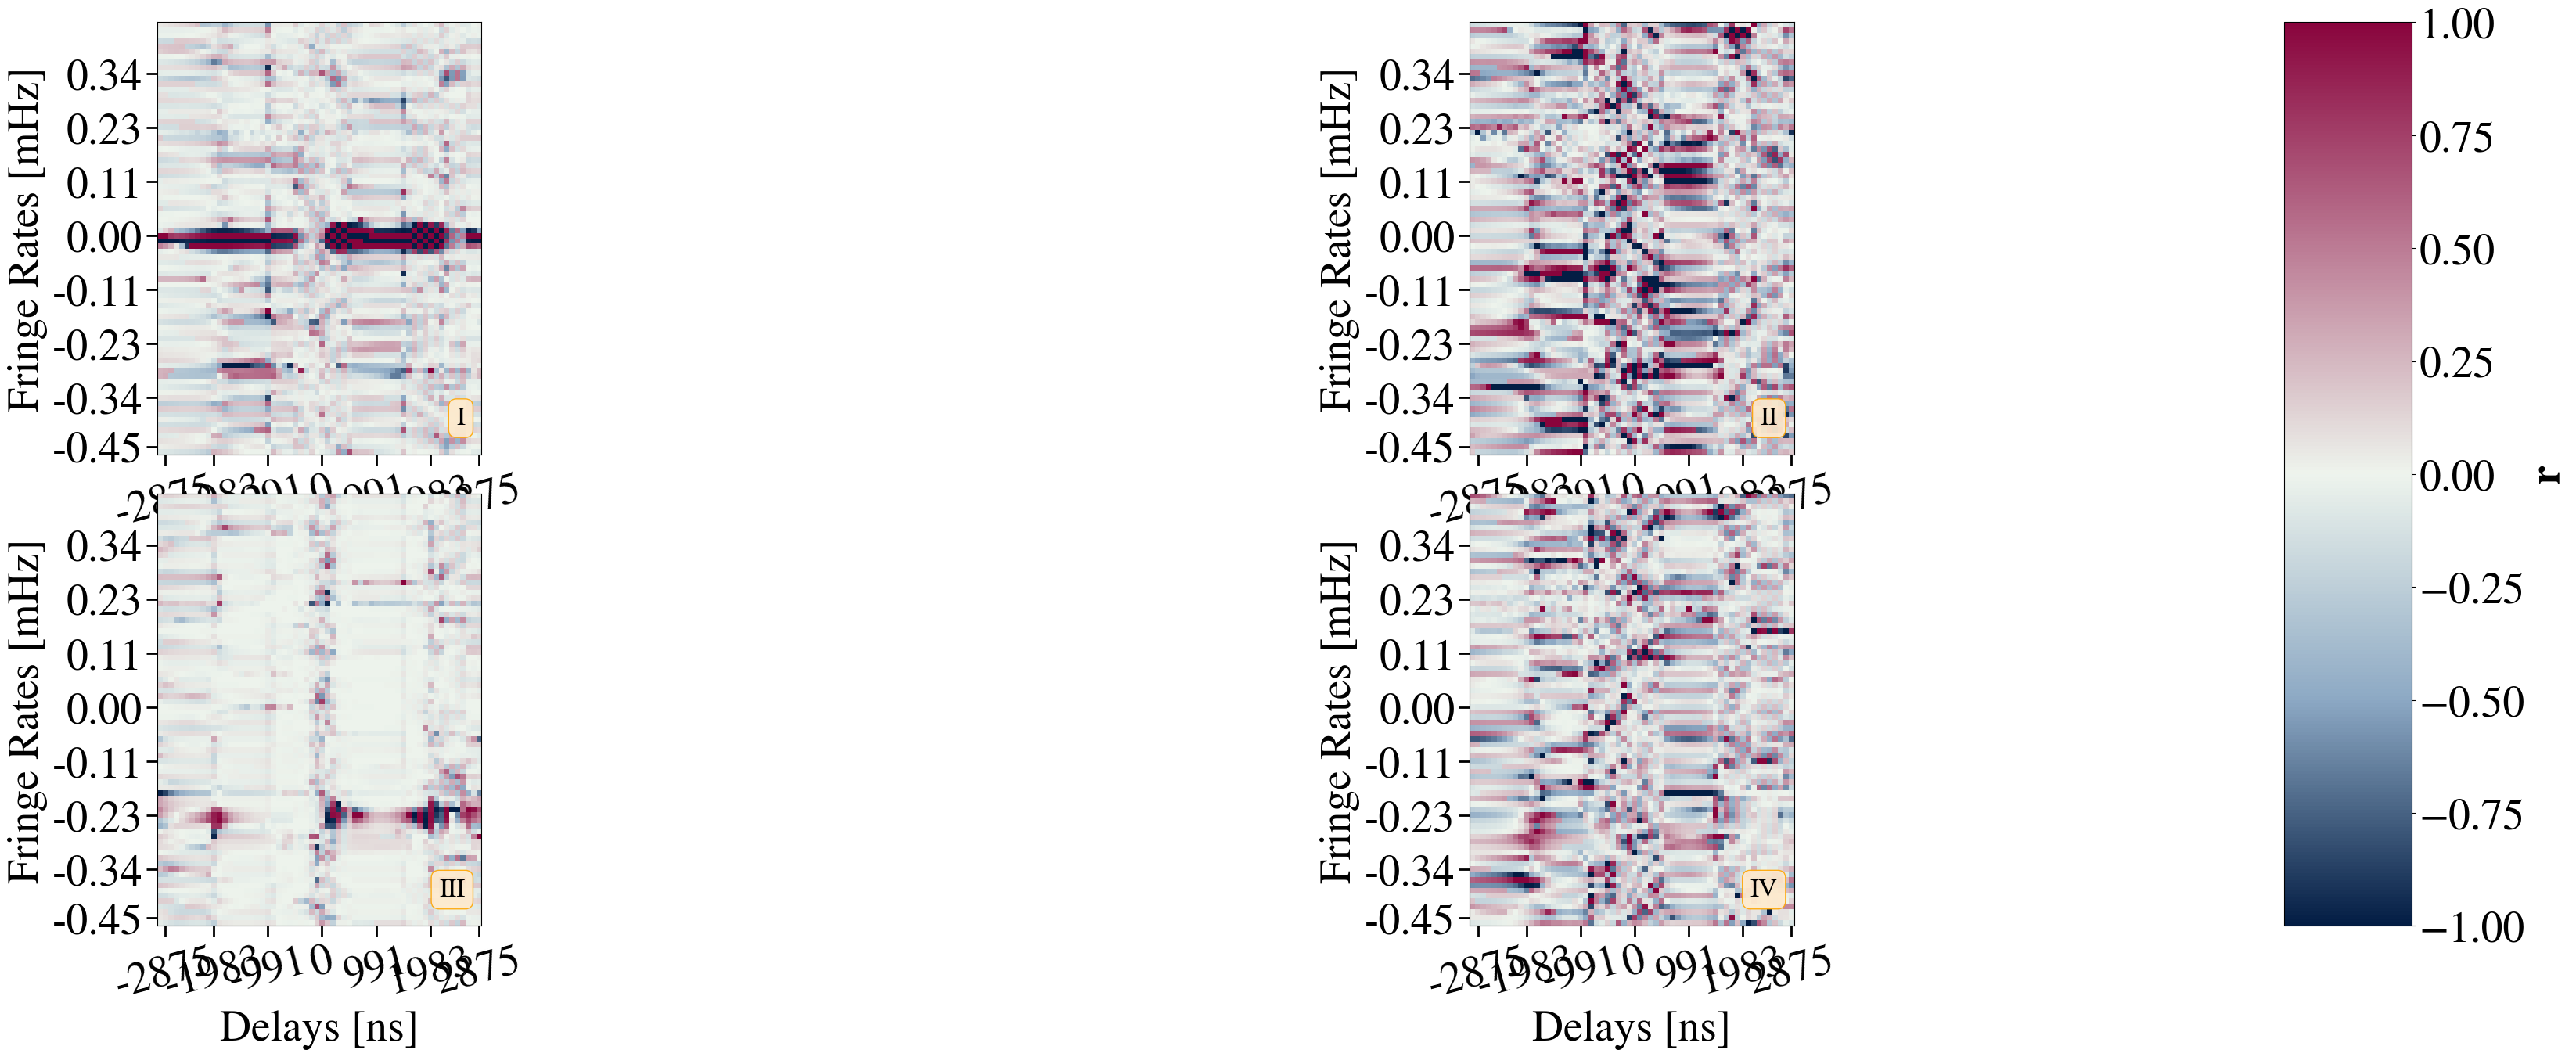

In [46]:
'''Loading Data'''
# result_dir='/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/1e7_bound/10modes'
# run_version_arr = ['low_dl_fr_0','high_dl_fr_0','low_dl_fr_20']
fig_labels = ['I','II','III','IV']
bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.9)

fig = plt.figure(figsize=(45,15))
axs = ImageGrid(
    fig, 111,
    nrows_ncols=(2, 2),
    axes_pad=0.5,
    share_all=True,
    label_mode="all",
    cbar_location="right",
    cbar_mode="single",
    cbar_size="5%",
    cbar_pad=0.2,
    aspect=False
)

Niter=100000
i=0
for run_version in run_version_arr:
    fgmodes=np.load(result_dir+run_version+'/fgmodes.npy') # Only for fg_fit

    fg_amps_gcr = np.load(result_dir+run_version+'/fg-amps.npy')
    b_sys_gcr = np.load(result_dir+run_version+'/b-sys.npy')

    '''Vis Arrays'''
    fg_vis_arr=np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    delta_g_arr = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')

    '''DLFR Arrays'''
    fg_dlfr_arr=np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    sys_model_dlfr_arr = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    delta_g_dlfr_arr = np.empty([Niter,Ntimes,Nfreqs],dtype='complex')
    print("Foregrounds...")
    for a in tqdm(range(Niter)):
        fg_vis_arr[a,:,:] = (fgmodes @ fg_amps_gcr[a,:].T).T
        fg_dlfr_arr[a,:,:] = data_dly_fr(fg_vis_arr[a,:,:],freqs*1e6, lsts, windows='blackman-harris')

    print("Systematics...")
    for a in tqdm(range(Niter)):
        delta_g_arr[a,:,:] = (sys_modes_operator @ b_sys_gcr[a,:]).reshape([Nfreqs,Ntimes]).T
        sys_model_dlfr_arr[a,:,:] = data_dly_fr(1+delta_g_arr[a,:,:],freqs*1e6, lsts, windows='blackman-harris')
        delta_g_dlfr_arr[a,:,:] = data_dly_fr(delta_g_arr[a,:,:],freqs*1e6, lsts, windows='blackman-harris')

    corr_map_fg = plot_crosscor_pearson(fg_dlfr_arr, delta_g_dlfr_arr)

    
    im=axs[i].imshow(corr_map_fg[::-1,:].real,cmap=paper_map,origin='lower',vmin=-1,vmax=1)
    axs[i].text(0.95,0.07,fig_labels[i],bbox=bbox,
            transform=axs[i].transAxes, horizontalalignment='right')
    i=i+1

cbar = axs.cbar_axes[0].colorbar(im)
cbar.set_label(r"$\mathbf{r}$", size=40)
cbar.ax.tick_params(labelsize=40)

for ax in axs:
    # ax[i,j].set_title(title_list[i][j],pad=15)
    ax.set_xlabel('Delays [ns]', fontsize=40)
    ax.set_ylabel('Fringe Rates [mHz]', fontsize=40)
    ax.tick_params(direction='out', length=6, width=2, colors='black',size=10, labelsize=40)
    ax.set_xticks(xticklocs,labels=xticklabels_dl, rotation=15)
    ax.set_yticks(yticklocs,labels=yticklabels_fr)

# plt.savefig(fig_dir+'/'+'fg_sys_corr.pdf',bbox_inches='tight',dpi=300)

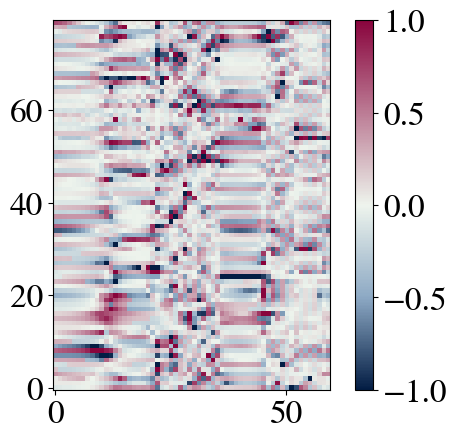

In [51]:
plt.imshow(corr_map_fg[::-1,:].real,cmap=paper_map,origin='lower',vmin=-1,vmax=1)
plt.colorbar()

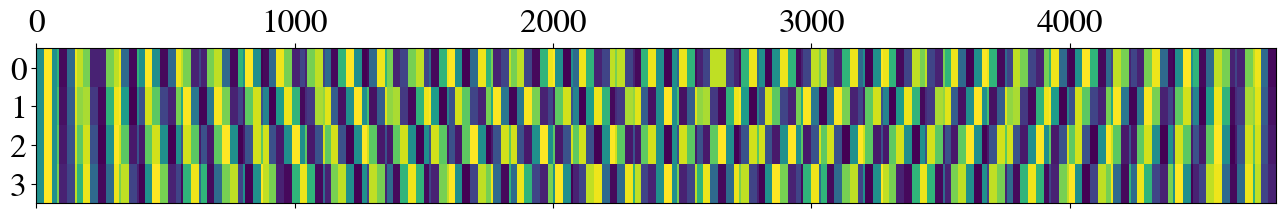

In [ ]:
plt.matshow(sys_modes_operator[:,0].reshape([Nfreqs,Ntimes],order='F').T.real,aspect='auto')

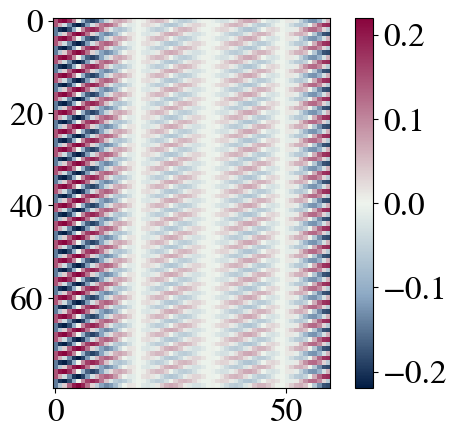

In [60]:
plt.imshow(delta_g_arr.mean(axis=0).imag,cmap=paper_map,norm=CenteredNorm())
plt.colorbar()

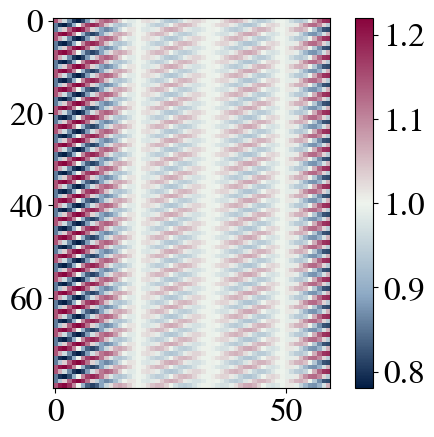

In [ ]:
plt.imshow(delta_g_arr[0].real,cmap=paper_map)
plt.colorbar()

In [8]:
fft1= np.fft.fftshift(fg_true)
fft1=np.fft.fftn(fft1)
fft1=np.fft.ifftshift(fft1)

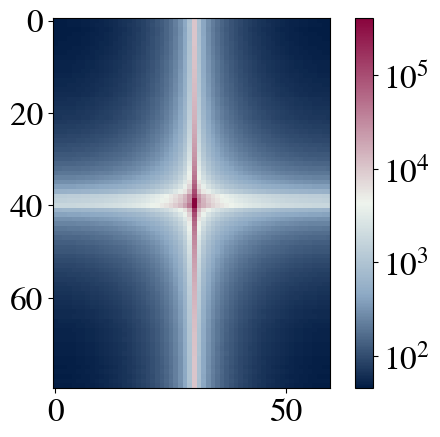

In [12]:
from matplotlib.colors import SymLogNorm

plt.imshow(np.abs(fft1),cmap=paper_map,norm=SymLogNorm(linthresh=1e-8))
plt.colorbar()

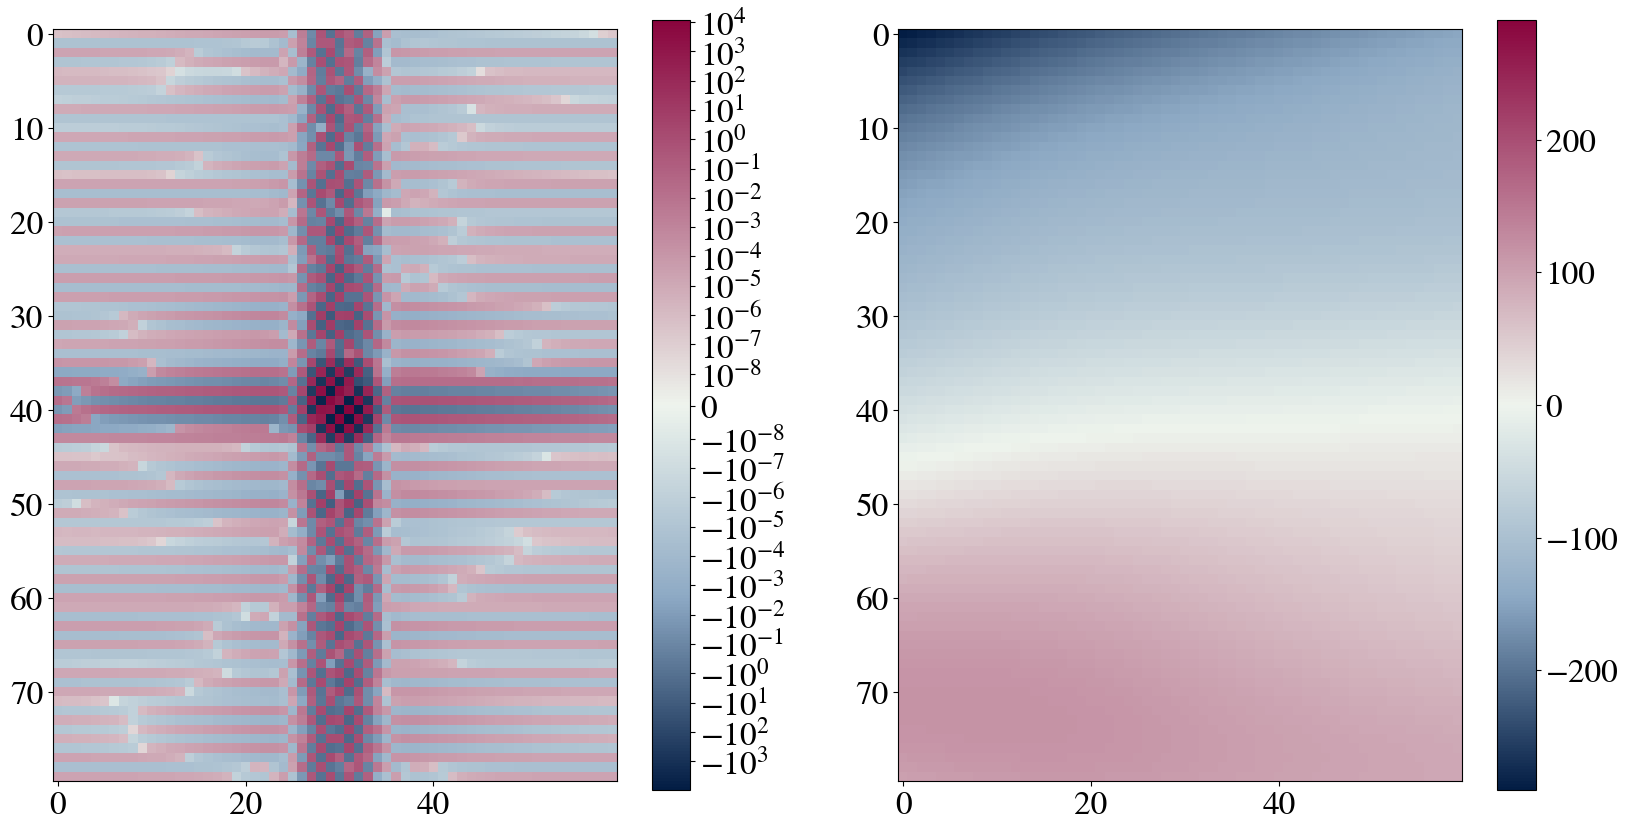

In [50]:
from matplotlib.colors import SymLogNorm, CenteredNorm
fig,ax=plt.subplots(1,2,figsize=(20,10))
im1=ax[0].imshow(np.real(data_dly_fr(fg_true,freqs*1e6, lsts, windows='blackman-harris')),cmap=paper_map,norm=SymLogNorm(linthresh=1e-8))
im2=ax[1].imshow(np.real(fg_true),cmap=paper_map,norm=CenteredNorm())
plt.colorbar(im1,ax=ax[0])
plt.colorbar(im2,ax=ax[1])